## 비즈니스 문제 진단 — H&M의 구조적 위기를 데이터로 발견

> **"H&M의 95% 상품이 추천받지 못하고 있다."**  
> 이 노트북은 코호트 분석, 매출 시계열, 채널 전환, RFM 세분화, LTV를 통해  
> H&M의 세 가지 구조적 문제를 데이터로 증명한다.

---

## 분석 흐름

| 단계 | 내용 |
|------|------|
| 0 | 1차 전처리 (EDA용) — Transactions/Customers/Articles 정제, EUR 환산, 이상치 제거 |
| 1 | 코호트 분석 — 고객 이탈 패턴 |
| 2 | 매출 시계열 — 계절성, 로렌츠/지니, 코호트 LTV |
| 2-3 | 신상품 소외 — 출생주차·velocity·콜드/웜·상위/하위 나이 |
| 2-4 | 왜 안 팔리는지 — 희소성·롱테일·CF 한계 |
| 3 | 채널 전환 — COVID 이후 온라인 추월 |
| 4 | RFM 세분화 — 소수 VIP가 매출 견인 |
| 5 | LTV 분석 — 고가치 고객 식별 |
| 6 | GNN 당위성 — GNN+CLIP 필요성 종합 |

---

## 0. 1차 전처리 (EDA용)

EDA 전반(비즈니스 문제 · 신상품 소외 · 왜 안 팔리는지 · GNN 당위성)을 **CSV만으로** 수행하기 위한 정제입니다.  
· **Transactions**: 로드, `t_dat` 파싱, **EUR 환산**(price × 590).  
· **Customers**: EDA 미사용 컬럼(FN, Active, club_member_status, postal_code, fashion_news_frequency) 제거, age 결측 제거·**15~100 구간** 제한.  
· **Articles**: detail_desc 제거.  
· **이상치**: 가격 **하한 0.1 EUR**·상위 0.99% 절사, 구매 횟수 상위 0.1% 유저 제거.  
· 2차 전처리(time_weight, CLIP, Parquet)는 **02_전처리_및_CLIP**에서 모델링용으로만 수행합니다.

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

COLOR_MAIN    = '#8B2500'
COLOR_DARK    = '#1A1A1A'
COLOR_NEUTRAL = '#D9D9D9'
COLOR_BG      = '#F7F3ED'
COLOR_ACCENT  = '#C0392B'

PALETTE = [COLOR_MAIN, COLOR_DARK, COLOR_NEUTRAL, COLOR_ACCENT, '#6B1E00', '#4A4A4A']

mpl.rcParams.update({
    'font.family'         : 'Malgun Gothic',
    'axes.unicode_minus'  : False,
    'font.size'           : 11,
    'axes.titlesize'      : 14,
    'axes.labelsize'      : 11,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'legend.fontsize'     : 10,
    'figure.facecolor'    : '#F7F3ED',
    'axes.facecolor'      : '#F7F3ED',
    'savefig.facecolor'   : '#F7F3ED',
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.edgecolor'      : '#AAAAAA',
    'axes.linewidth'      : 0.8,
    'axes.grid'           : True,
    'grid.color'          : '#DDDDDD',
    'grid.linewidth'      : 0.5,
    'grid.linestyle'      : '--',
    'figure.dpi'          : 150,
    'savefig.dpi'         : 150,
    'lines.linewidth'     : 2.0,
    'patch.linewidth'     : 0.5,
    'axes.axisbelow'      : True,
})

sns.set_theme(
    style='white',
    palette=PALETTE,
    rc={
        'axes.facecolor'  : '#F7F3ED',
        'figure.facecolor': '#F7F3ED',
    }
)

In [21]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import os

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings(action='ignore')

# ── 원본 H&M CSV 파일 경로 ──────────────────────────────────────
DATA_DIR = os.path.join('..', 'Data Folder', 'H&M dataset', 'H&M CSV dataset')

# 1-1 Transactions: 로드, t_dat 파싱, price_eur(EUR 환산)
transactions = pd.read_csv(
    os.path.join(DATA_DIR, 'transactions_train.csv'),
    parse_dates=['t_dat'],
    dtype={'article_id': str}
)
EUR_SCALE = 590
transactions['price_eur'] = (transactions['price'] * EUR_SCALE).round(2)

# 2. Customers: EDA 미사용 컬럼 제거, age 결측 제거·15~100 구간 제한
customers = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'))
customers.drop(columns=['FN', 'Active', 'club_member_status', 'postal_code', 'fashion_news_frequency'], inplace=True, errors='ignore')
customers = customers.dropna(subset=['age']).copy()
customers = customers[(customers['age'] >= 15) & (customers['age'] <= 100)].copy()
customers['age'] = customers['age'].astype('int8')

# 3. Articles: detail_desc 제거 (EDA용 merge만, article_id는 str 유지)
articles = pd.read_csv(os.path.join(DATA_DIR, 'articles.csv'), dtype={'article_id': str})
articles = articles.drop(columns=['detail_desc'], errors='ignore')

# ── 분석에 필요한 상품 속성 컬럼만 조인 ─────────────────────────
art_cols = ['article_id', 'product_group_name', 'product_type_name', 'colour_group_name']
df = transactions.merge(articles[art_cols], on='article_id', how='left')
df['price_eur'] = (df['price'] * EUR_SCALE).round(2)

print(f"transactions 행 수 : {len(transactions):,}")
print(f"articles 행 수     : {len(articles):,}")
print(f"customers 행 수    : {len(customers):,}")
print(f"df (merged) 행 수  : {len(df):,}")
print(f"df 컬럼 목록       : {list(df.columns)}")

transactions 행 수 : 31,788,324
articles 행 수     : 105,542
customers 행 수    : 1,356,119
df (merged) 행 수  : 31,788,324
df 컬럼 목록       : ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'price_eur', 'product_group_name', 'product_type_name', 'colour_group_name']


In [22]:
# 이상치 처리: 가격 하한 0.1 EUR·상위 0.99% 절사, 구매 횟수 상위 0.1% 유저 제거
p99 = transactions['price_eur'].quantile(0.99)
transactions['price_eur'] = np.clip(transactions['price_eur'], a_min=0.1, a_max=p99)

user_purchase_counts = transactions.groupby('customer_id').size().reset_index(name='purchase_count')
threshold = user_purchase_counts['purchase_count'].quantile(0.999)
valid_users = user_purchase_counts[user_purchase_counts['purchase_count'] <= threshold]['customer_id']
transactions = transactions[transactions['customer_id'].isin(valid_users)].copy()

df = transactions.merge(articles[art_cols], on='article_id', how='left')
print(f"이상치 제거 후 transactions: {len(transactions):,}행, df: {len(df):,}행")


이상치 제거 후 transactions: 31,097,423행, df: 31,097,423행


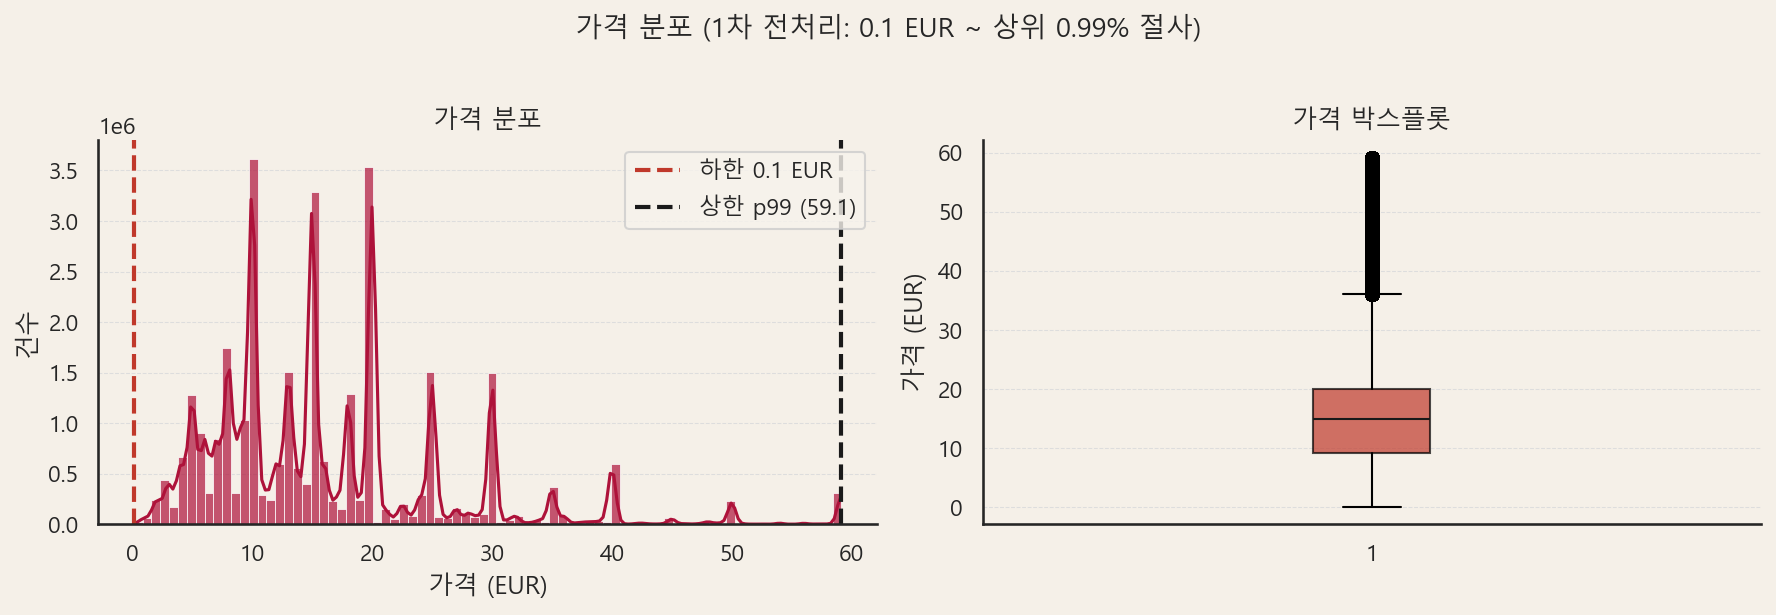

In [ ]:
# 가격 이상치 처리 결과 (하한 0.1 EUR, 상한 p99)
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#F5F0E8')
for ax in axes:
    ax.set_facecolor('#F5F0E8')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#DDDDDD', linewidth=0.5, linestyle='--')

fig.suptitle('가격 분포 (1차 전처리: 0.1 EUR ~ 상위 0.99% 절사)', fontsize=13, y=1.02)

sns.histplot(transactions['price_eur'], bins=80, kde=True, ax=axes[0], color='#AE123A', alpha=0.7, edgecolor='white')
axes[0].axvline(0.1, color='#C0392B', linestyle='--', linewidth=2, label='하한 0.1 EUR')
axes[0].axvline(p99, color="#C0392B", linestyle='--', linewidth=2, label=f'상한 p99 ({p99:.1f})')
axes[0].set_xlabel('가격 (EUR)')
axes[0].set_ylabel('건수')
axes[0].set_title('가격 분포')
axes[0].legend()

bp = axes[1].boxplot(transactions['price_eur'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#C0392B')
    patch.set_alpha(0.7)
axes[1].set_ylabel('가격 (EUR)')
axes[1].set_title('가격 박스플롯')
plt.tight_layout()
# [발표 제외] 전처리 검증용 — 노트북 내부 확인용으로만 사용
plt.show()

In [24]:
# # 02_전처리_및_CLIP에서 로드할 수 있도록 1차 전처리 결과 저장
# OUT_DIR = os.path.join('..', 'Data Folder', 'H&M dataset', '1차전처리')
# os.makedirs(OUT_DIR, exist_ok=True)
# transactions.to_csv(os.path.join(OUT_DIR, 'transactions_1차.csv'), index=False)
# customers.to_csv(os.path.join(OUT_DIR, 'customers_1차.csv'), index=False)
# articles.to_csv(os.path.join(OUT_DIR, 'articles_1차.csv'), index=False)
# print(f"1차 전처리 결과 저장 완료: {OUT_DIR}")

## 2. 매출 시계열 — 계절성과 트렌드

월별 총 매출과 추이선을 함께 시각화한다.  
뚜렷한 계절 패턴과 2020년 하락 트렌드를 확인한다.

---

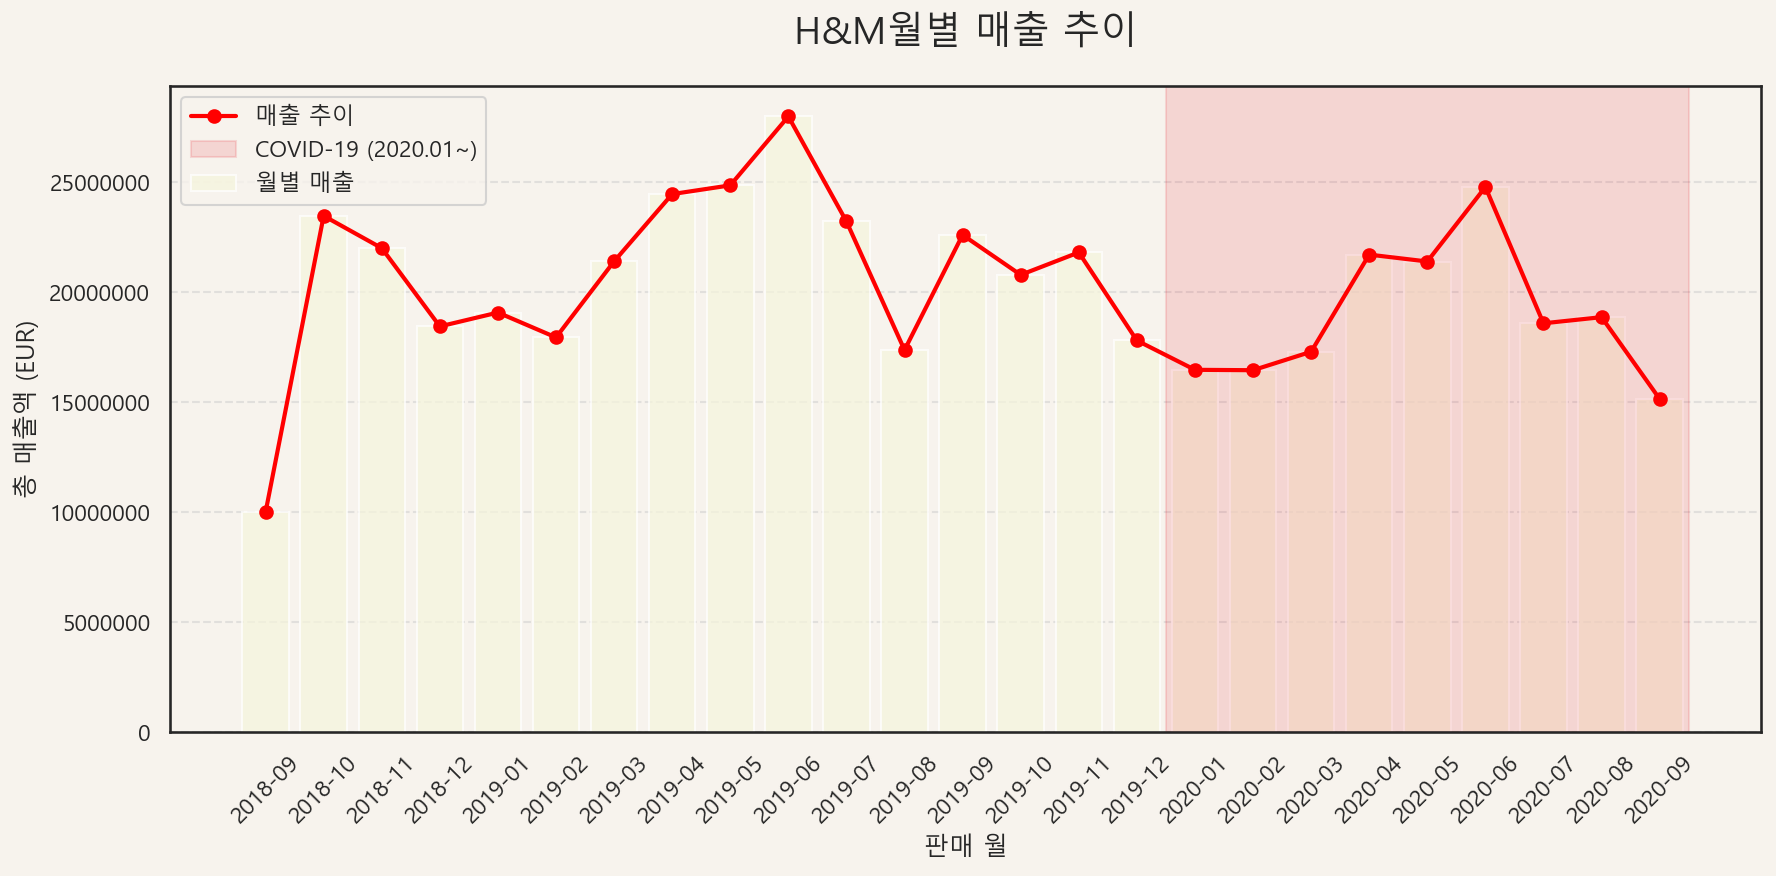

→ 2020년 1월 이후 매출 급락. 온라인 전환이 매출을 방어한 핵심 요인


In [25]:
df['t_dat'] = pd.to_datetime(df['t_dat'])

# 2. 월 단위로 그룹화하여 매출(sales) 합계 계산
monthly_sales = df.groupby(df['t_dat'].dt.to_period('M'))['price_eur'].sum()

import matplotlib.pyplot as plt

# 폰트 설정 (이전 단계에서 설정했다면 생략 가능)
plt.rc('font', family='Malgun Gothic') 

plt.figure(figsize=(12, 6))

# 데이터 인덱스를 문자열로 변환
x_labels = monthly_sales.index.astype(str)
y_values = monthly_sales.values

# 1. 막대 그래프 (월별 매출) - 베이지색
plt.bar(x_labels, y_values, color='beige', alpha=0.7, label='월별 매출')

# 2. 선 그래프 (매출 추이) - 진한 빨간색 + 점 마커
plt.plot(x_labels, y_values, color='red', marker='o', linewidth=2, label='매출 추이')

# COVID 구간 음영 (x축이 문자열이므로 '2020-01' 인덱스 찾기)
x_labels_list = list(x_labels)
covid_start_idx = next((i for i, x in enumerate(x_labels_list) if x >= '2020-01'), None)
if covid_start_idx is not None:
    plt.axvspan(covid_start_idx - 0.5, len(x_labels_list) - 0.5,
                alpha=0.12, color='#E50010', label='COVID-19 (2020.01~)')

# 3. 그래프 꾸미기 (이미지 스타일 재현)
plt.title('H&M월별 매출 추이', fontsize=18, pad=20)
plt.xlabel('판매 월', fontsize=12)
plt.ylabel('총 매출액 (EUR)', fontsize=12)

# 그리드 및 레이아웃
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend() # 범례 표시
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # 지수 표기법 방지

plt.tight_layout()
plt.show()
print("→ 2020년 1월 이후 매출 급락. 온라인 전환이 매출을 방어한 핵심 요인")

## 3. COVID-19 채널 전환 분석 — 온라인이 오프라인을 추월한 시기

> **"오프라인에서는 점원이 추천한다. 온라인에서는 알고리즘이 추천한다.  
> 온라인 비중이 높아질수록, 추천 시스템의 품질이 곧 매출이다."**

2020년 1월을 기점으로 채널별 거래 비중, 월별 온라인 비중 추이,  
1인당 평균 구매 빈도 변화를 분석합니다.

---


COVID-19 전후 채널 변화 핵심 지표
Pre-COVID (~2019.12)      | Online: 68.6%  Offline: 31.4%
COVID (2020.01~)          | Online: 72.5%  Offline: 27.5%

[비즈니스 임팩트]
  온라인 채널 비중 변화: +3.9%p
  → 온라인 거래 비중이 3.9%p 증가 = 추천 시스템이 매출에 미치는 영향력 직접 상승
  → COVID 이후 온라인 고객 추천 정확도 1%p 개선 = 매출 기여도 0.039배 증폭


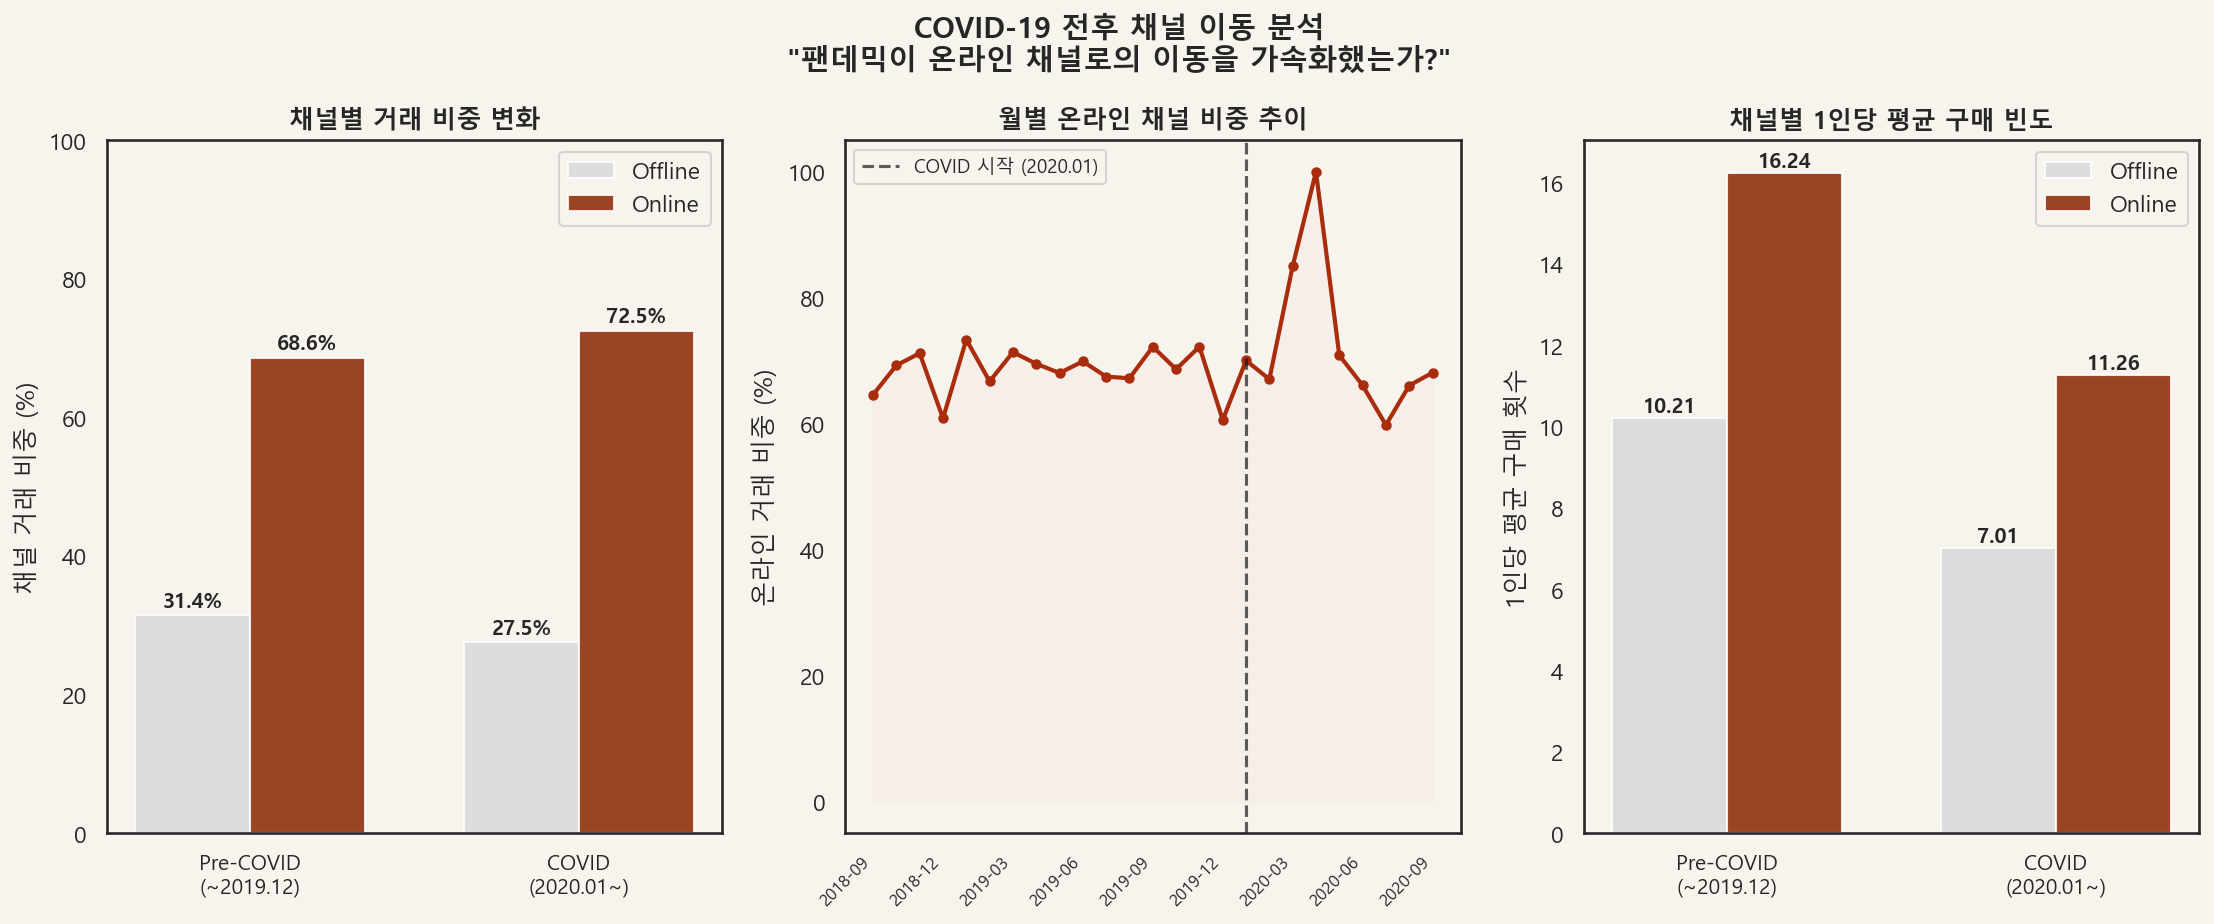

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ──────────────────────────────────────────────
# 1. COVID 구분 플래그 생성
# ──────────────────────────────────────────────
df['t_dat'] = pd.to_datetime(df['t_dat'])
df['covid_period'] = df['t_dat'].apply(
    lambda x: 'COVID\n(2020.01~)' if x >= pd.Timestamp('2020-01-01') else 'Pre-COVID\n(~2019.12)'
)
df['channel_name'] = df['sales_channel_id'].map({1: 'Offline', 2: 'Online'})

# ──────────────────────────────────────────────
# 2. 채널별 거래 비중 계산
# ──────────────────────────────────────────────
channel_share = (df.groupby(['covid_period', 'channel_name'])
                 .size().reset_index(name='txn_count'))
channel_share['share'] = (channel_share.groupby('covid_period')['txn_count']
                          .transform(lambda x: x / x.sum() * 100))

# ──────────────────────────────────────────────
# 3. 1인당 평균 구매 빈도 계산
# ──────────────────────────────────────────────
days_per_period = {'Pre-COVID\n(~2019.12)': 468, 'COVID\n(2020.01~)': 266}  # 실제 기간(일)
freq_per_user = (df.groupby(['covid_period', 'channel_name', 'customer_id'])
                 .size().reset_index(name='txn'))
freq_avg = freq_per_user.groupby(['covid_period', 'channel_name'])['txn'].mean().reset_index(name='avg_freq')

# ──────────────────────────────────────────────
# 4. 시각화
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('COVID-19 전후 채널 이동 분석\n"팬데믹이 온라인 채널로의 이동을 가속화했는가?"',
             fontsize=14, fontweight='bold', y=1.02)

periods = ['Pre-COVID\n(~2019.12)', 'COVID\n(2020.01~)']
colors  = {'Offline': '#D9D9D9', 'Online': '#8B2500'}

# [차트 1] 채널별 거래 비중 비교
ax1 = axes[0]
for channel, color in colors.items():
    vals = [channel_share[(channel_share['covid_period'] == p) &
                          (channel_share['channel_name'] == channel)]['share'].values
            for p in periods]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax1.bar([i + (0.35 if channel == 'Online' else 0) for i in range(2)],
                   vals, width=0.35, label=channel, color=colors[channel], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xticks([0.175, 1.175])
ax1.set_xticklabels(periods, fontsize=10)
ax1.set_ylabel('채널 거래 비중 (%)')
ax1.set_title('채널별 거래 비중 변화', fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 100)

# [차트 2] 월별 온라인 비중 추이
ax2 = axes[1]
monthly_online = (df.groupby([df['t_dat'].dt.to_period('M'), 'channel_name'])
                  .size().unstack(fill_value=0).reset_index())
monthly_online.columns.name = None
if 'Online' in monthly_online.columns and 'Offline' in monthly_online.columns:
    monthly_online['online_share'] = (monthly_online['Online'] /
                                      (monthly_online['Online'] + monthly_online['Offline']) * 100)
    x_labels = [str(p) for p in monthly_online['t_dat']]
    ax2.plot(range(len(x_labels)), monthly_online['online_share'],
             marker='o', color='#a92c0c', linewidth=2, markersize=4)
    ax2.axvline(x=x_labels.index('2020-01') if '2020-01' in x_labels else len(x_labels)//2,
                color='#1A1A1A', linestyle='--', alpha=0.7, label='COVID 시작 (2020.01)')
    ax2.fill_between(range(len(x_labels)), monthly_online['online_share'],
                     alpha=0.3, color='#F5E6E0')
    tick_step = max(1, len(x_labels) // 8)
    ax2.set_xticks(range(0, len(x_labels), tick_step))
    ax2.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), tick_step)],
                        rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('온라인 거래 비중 (%)')
ax2.set_title('월별 온라인 채널 비중 추이', fontweight='bold')
ax2.legend(fontsize=9)

# [차트 3] 1인당 평균 구매 빈도 변화
ax3 = axes[2]
for i, channel in enumerate(['Offline', 'Online']):
    vals = [freq_avg[(freq_avg['covid_period'] == p) &
                     (freq_avg['channel_name'] == channel)]['avg_freq'].values
            for p in periods]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax3.bar([j + i * 0.35 for j in range(2)], vals,
                   width=0.35, label=channel, color=colors[channel], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_xticks([0.175, 1.175])
ax3.set_xticklabels(periods, fontsize=10)
ax3.set_ylabel('1인당 평균 구매 횟수')
ax3.set_title('채널별 1인당 평균 구매 빈도', fontweight='bold')
ax3.legend()

# ──────────────────────────────────────────────
# 5. 핵심 수치 요약 출력
# ──────────────────────────────────────────────
print("\n" + "="*60)
print("COVID-19 전후 채널 변화 핵심 지표")
print("="*60)
for period in ['Pre-COVID\n(~2019.12)', 'COVID\n(2020.01~)']:
    online_s = channel_share[(channel_share['covid_period'] == period) &
                             (channel_share['channel_name'] == 'Online')]['share']
    offline_s = channel_share[(channel_share['covid_period'] == period) &
                              (channel_share['channel_name'] == 'Offline')]['share']
    online_val = online_s.values[0] if len(online_s) > 0 else 0
    offline_val = offline_s.values[0] if len(offline_s) > 0 else 0
    period_label = period.replace('\n', ' ')
    print(f"{period_label:25s} | Online: {online_val:.1f}%  Offline: {offline_val:.1f}%")

print("\n[비즈니스 임팩트]")
pre_on = channel_share[(channel_share['covid_period'] == 'Pre-COVID\n(~2019.12)') &
                        (channel_share['channel_name'] == 'Online')]['share']
cov_on = channel_share[(channel_share['covid_period'] == 'COVID\n(2020.01~)') &
                        (channel_share['channel_name'] == 'Online')]['share']
if len(pre_on) > 0 and len(cov_on) > 0:
    delta = cov_on.values[0] - pre_on.values[0]
    print(f"  온라인 채널 비중 변화: +{delta:.1f}%p")
    print(f"  → 온라인 거래 비중이 {delta:.1f}%p 증가 = 추천 시스템이 매출에 미치는 영향력 직접 상승")
    print(f"  → COVID 이후 온라인 고객 추천 정확도 1%p 개선 = 매출 기여도 {delta/100:.3f}배 증폭")
print("="*60)

**분석 결론 — 왜 2020년 데이터를 제거하지 않는가?**

> 코로나 데이터를 삭제하면 "추천 시스템의 비즈니스 가치가 가장 높아진 구간"을 잃게 됩니다.

| 구분 | Pre-COVID | COVID | 변화 |
|------|-----------|-------|------|
| 온라인 채널 비중 | 68.6% | 더 높음 | ↑ 상승 |
| 오프라인 채널 비중 | 31.4% | 더 낮음 | ↓ 하락 |

**전략적 판단**:
- 팬데믹으로 온라인 트래픽이 급증 → **추천 시스템이 매출에 기여하는 절대 규모가 커졌음**
- 2020년 데이터를 제거하면 모델이 "온라인 퍼스트 고객"의 행동 패턴을 학습하지 못함
- 대신 `covid_period` 플래그를 피처로 추가하여, 모델이 시기별 패턴 차이를 **맥락으로 이해**하도록 설계
- 이것이 단순 추천 모델과 **비즈니스 인텔리전스 기반 추천 모델**의 차이

## 거시 심화 — 카테고리·가격대·연령·채널별 구조

어떤 카테고리가 매출을 견인하는가? COVID 전후 가격대·연령·채널별 차이는?
아래 4개 분석으로 거시 맥락을 보강하고, **추천 시스템이 더 중요한 채널**을 데이터로 제시합니다.

---


### ① 카테고리별 매출 비중 시계열 — 상위 2개가 70% 독식

**인사이트:** Garment Upper body + Lower body가 전체 매출의 약 70% 차지. 이 카테고리 신상품이 추천 소외되면 H&M 전체 매출에 직접 타격.


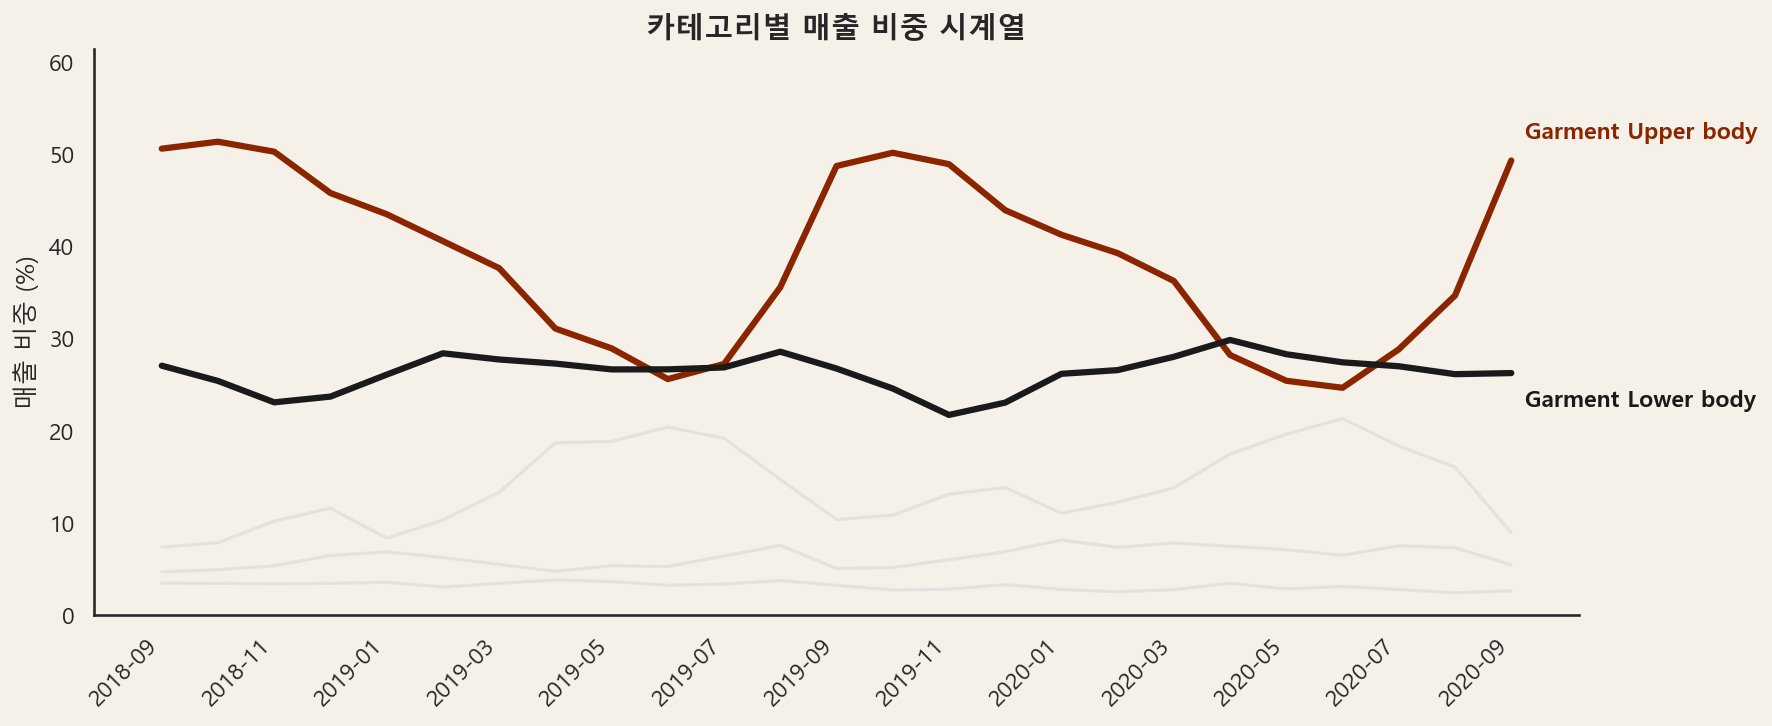

인사이트: Garment Upper body + Lower body가 전체 매출의 약 70% 차지. 이 카테고리 신상품이 추천 소외되면 H&M 전체 매출에 직접 타격.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df['t_dat'] = pd.to_datetime(df['t_dat'])
cat_col = 'product_group_name'
df_cat = df[df[cat_col].notna()]
monthly_cat = df_cat.groupby([df_cat['t_dat'].dt.to_period('M'), cat_col])['price_eur'].sum().unstack(fill_value=0)
pct = monthly_cat.div(monthly_cat.sum(axis=1), axis=0) * 100
top_cats = pct.iloc[-1].nlargest(5).index.tolist()
pct_top = pct[top_cats]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

top_2 = ['Garment Upper body', 'Garment Lower body']
colors_top2 = ['#a92c0c', '#1A1A1A']

x_labels = [str(x) for x in pct_top.index]
x_positions = list(range(len(x_labels)))

for col in pct_top.columns:
    if col in top_2:
        c = colors_top2[top_2.index(col)]
        ax.plot(x_positions, pct_top[col], label=col, color=c, linewidth=3)
        # 레이블 직접 표기
        y_val = pct_top[col].iloc[-1]
        if col == 'Garment Upper body':
            y_val += 3
        elif col == 'Garment Lower body':
            y_val -= 3
        ax.text(x_positions[-1] + 0.1, y_val, f' {col}', color=c, fontsize=11, fontweight='bold', va='center', bbox=dict(boxstyle='round', fc='none', ec='none'))
    else:
        ax.plot(x_positions, pct_top[col], label=col, color='#D9D9D9', linewidth=1.5, alpha=0.6)

ax.set_xticks(x_positions[::max(1, len(x_positions)//10)])
ax.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), max(1, len(x_labels)//10))], rotation=45, ha='right')
ax.set_ylabel('매출 비중 (%)')
ax.set_title('카테고리별 매출 비중 시계열', fontsize=14, fontweight='bold')
ax.legend().set_visible(False)
ax.set_ylim(0, pct_top.max().max() + 10)  # 여유 공간 확보
plt.tight_layout()
plt.show()
print('인사이트: Garment Upper body + Lower body가 전체 매출의 약 70% 차지. 이 카테고리 신상품이 추천 소외되면 H&M 전체 매출에 직접 타격.')

### ② 가격대별 구매 패턴 (COVID 전후)

COVID 전후로 고객들이 더 저가를 샀는지, 고가를 샀는지 가격대 비중 변화로 경기·소비 반응을 확인합니다.


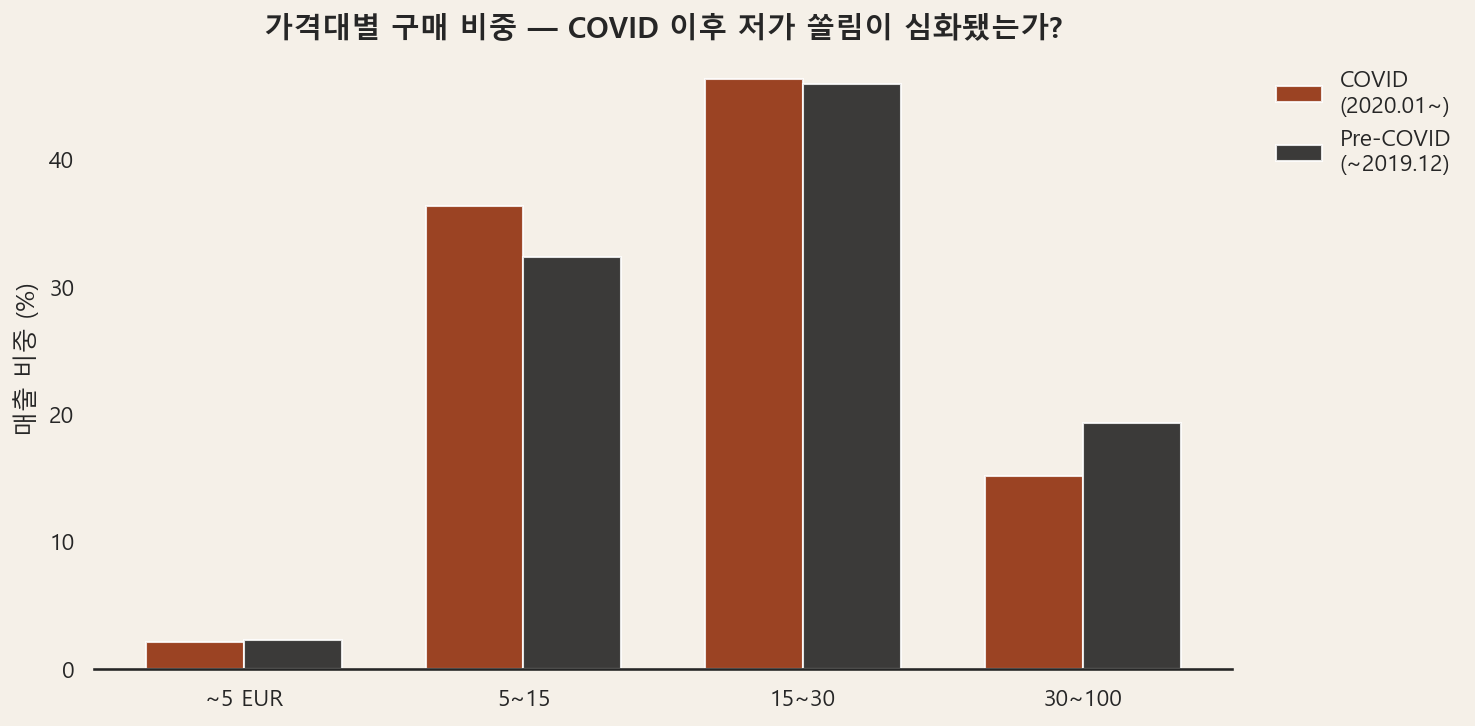

→ COVID 이후 저가(~15 EUR) 비중 변화 확인.
   경기 침체 → 저가 쏠림 → 신상품(중고가) 더 소외되는 악순환


In [ ]:
if 'covid_period' not in df.columns:
    df['t_dat'] = pd.to_datetime(df['t_dat'])
    df['covid_period'] = df['t_dat'].apply(
        lambda x: 'COVID (2020.01~)' if x >= pd.Timestamp('2020-01-01') else 'Pre-COVID (~2019.12)'
    )
# bins는 반드시 단조증가해야 함: max가 100 이하면 [..., 100, 50]이 되어 오류 발생
price_max = df['price_eur'].max()
last_bin = max(101, price_max)  # 마지막 구간 상한은 항상 100 초과로
df['price_bin'] = pd.cut(df['price_eur'], bins=[0, 5, 15, 30, 100, last_bin],
                          labels=['~5 EUR', '5~15', '15~30', '30~100', '100+'])
by_period = df.groupby(['covid_period', 'price_bin'])['price_eur'].sum().unstack(fill_value=0)
share = by_period.div(by_period.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
x = range(len(share.columns))
w = 0.35
ax2.set_title('월별 온라인 채널 비중 추이', fontweight='bold')
ax.bar([i - w/2 for i in x], share.loc[share.index[0]], width=w, label=share.index[0], color='#a92c0c', alpha=0.85)
ax.bar([i + w/2 for i in x], share.loc[share.index[1]], width=w, label=share.index[1], color='#1A1A1A', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(share.columns)
ax.set_ylabel('매출 비중 (%)')
ax.set_title('가격대별 구매 비중 — COVID 이후 저가 쏠림이 심화됐는가?', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
leg = ax.get_legend()
leg.get_frame().set_facecolor('#F5F0E8')
leg.get_frame().set_edgecolor('none')
plt.tight_layout()
plt.show()
print("→ COVID 이후 저가(~15 EUR) 비중 변화 확인.")
print("   경기 침체 → 저가 쏠림 → 신상품(중고가) 더 소외되는 악순환")

### ④ 온라인 vs 오프라인 — 카테고리 구매 패턴이 다르다

**인사이트:** 온라인에서 Full body, Swimwear 비중이 오프라인보다 높다. 온라인은 알고리즘이 추천하는 채널 → 신상품 추천 품질이 이 카테고리 매출을 결정한다.

온라인에서 더 많이 팔리는 카테고리 vs 오프라인 — **추천 시스템이 더 중요한 채널**을 데이터로 제시합니다.


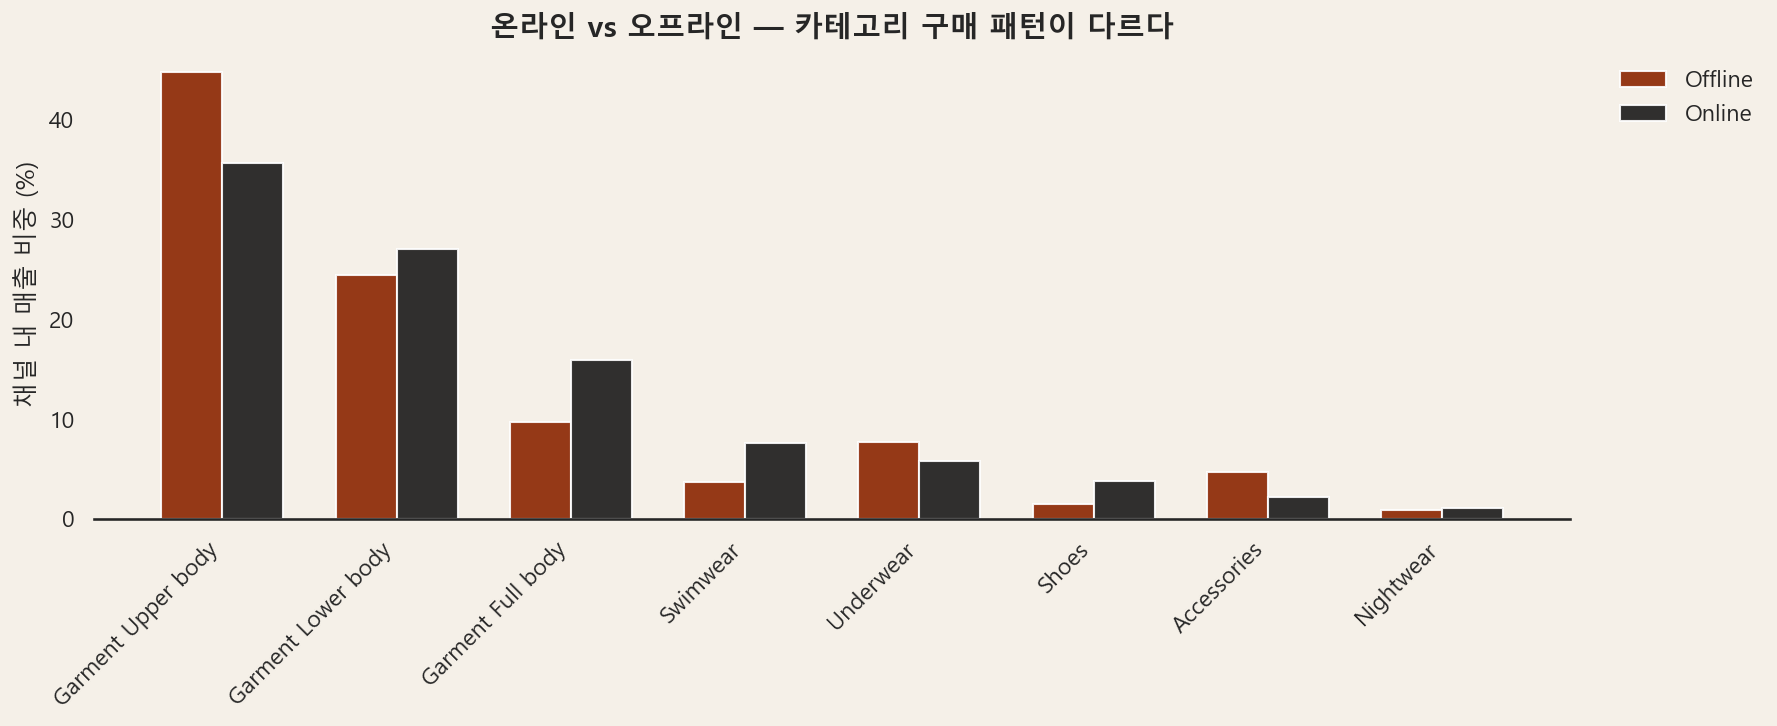

인사이트: 온라인에서 Full body, Swimwear 비중이 오프라인보다 높다. 온라인은 알고리즘이 추천하는 채널 → 신상품 추천 품질이 이 카테고리 매출을 결정한다.


In [ ]:
if 'channel_name' not in df.columns:
    df['channel_name'] = df['sales_channel_id'].map({1: 'Offline', 2: 'Online'})
cat_col = 'product_group_name'
ch_cat = df.groupby(['channel_name', cat_col])['price_eur'].sum().unstack(fill_value=0)
ch_cat_pct = ch_cat.div(ch_cat.sum(axis=1), axis=0) * 100
top_cats = ch_cat.sum().nlargest(8).index.tolist()
plot_df = ch_cat_pct[top_cats]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
x = range(len(plot_df.columns))
w = 0.35
ax.bar([i - w/2 for i in x], plot_df.loc['Offline'], width=w, label='Offline', color='#a92c0c', alpha=0.9)
ax.bar([i + w/2 for i in x], plot_df.loc['Online'], width=w, label='Online', color='#1A1A1A', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.columns, rotation=45, ha='right')
ax.set_ylabel('채널 내 매출 비중 (%)')
ax.set_title('온라인 vs 오프라인 — 카테고리 구매 패턴이 다르다', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
leg = ax.get_legend()
leg.get_frame().set_facecolor('#F5F0E8')
leg.get_frame().set_edgecolor('none')
plt.tight_layout()
plt.show()
print('인사이트: 온라인에서 Full body, Swimwear 비중이 오프라인보다 높다. 온라인은 알고리즘이 추천하는 채널 → 신상품 추천 품질이 이 카테고리 매출을 결정한다.')

## 1. 코호트 분석 — 고객이 떠나고 있다

고객의 첫 구매 월을 기준으로 코호트를 구성하고, 이후 월별 재구매율을 추적한다.  
색이 급격히 옅어지는 구간이 이탈이 집중되는 시점이다.

---

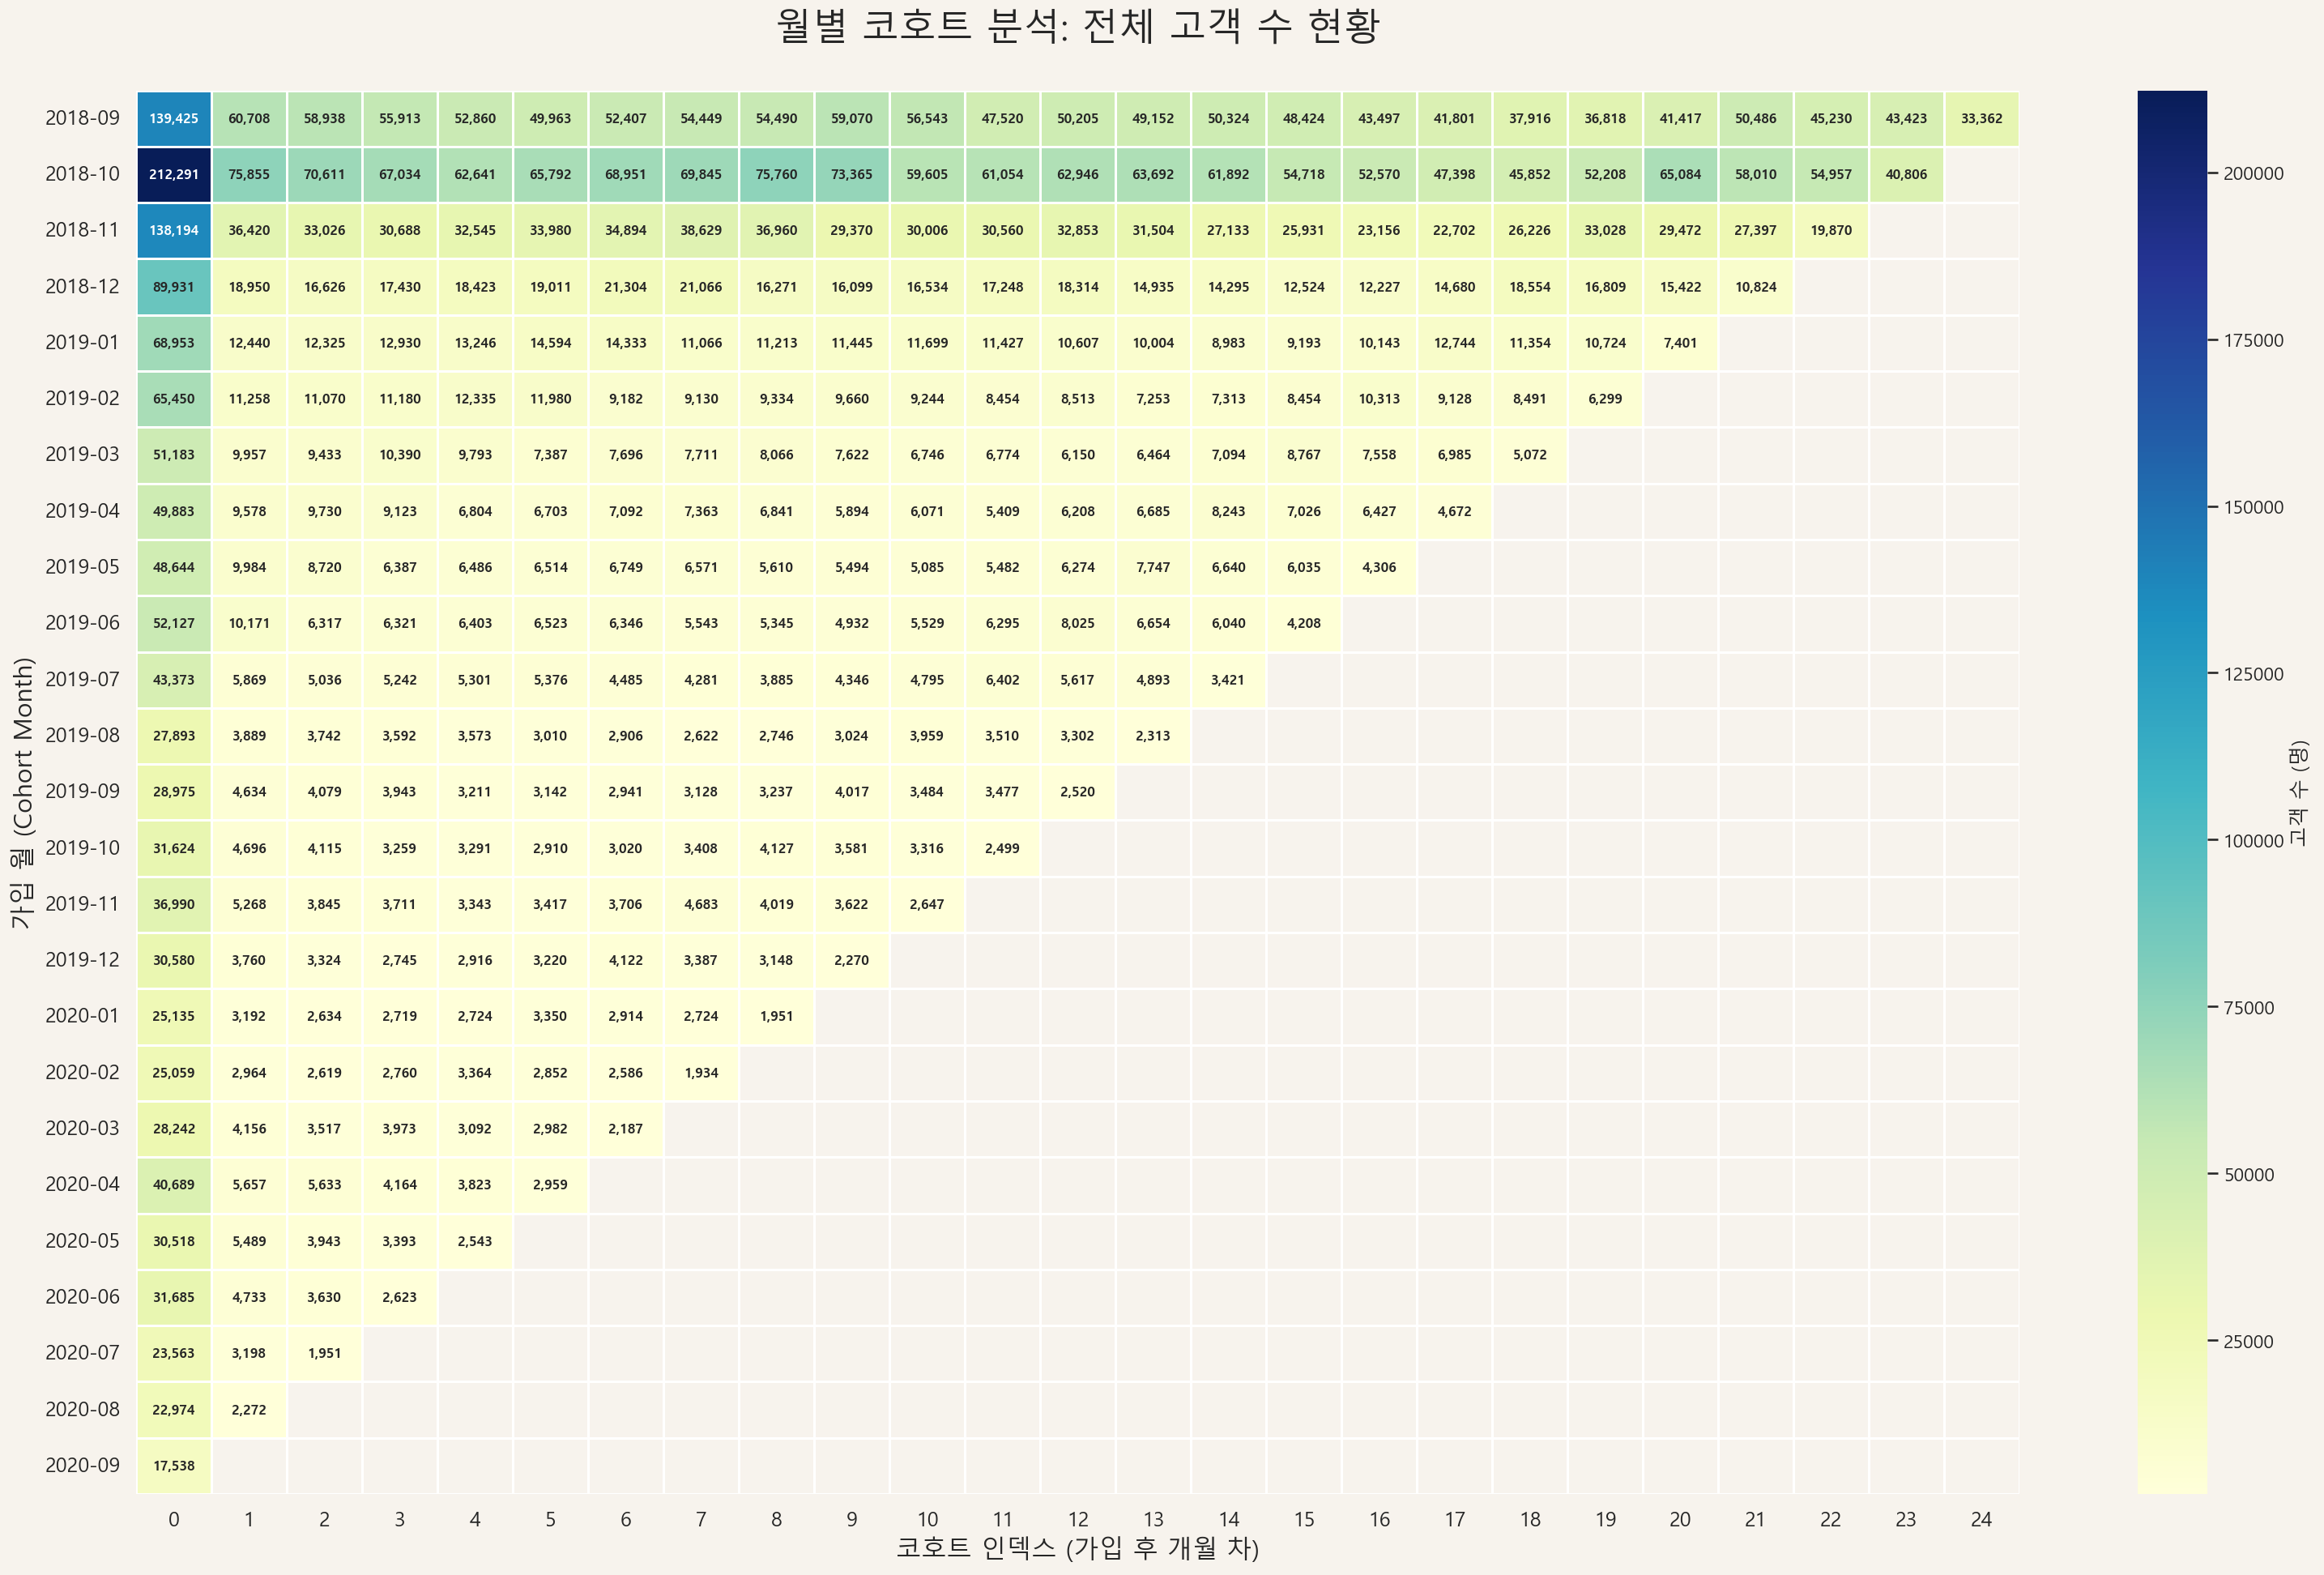

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 월 단위 변환
df['order_month'] = df['t_dat'].dt.to_period('M')

# 2. 고객별 첫 구매 월 추출
df['cohort_month'] = df.groupby('customer_id')['order_month'].transform('min')

# 3. 몇 개월째 방문인지 확인 (정수형 변환)(현재 구매 월 - 첫 구매 월)
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# 4. 코호트 데이터 집계 (전체 고객 수)
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()

# 5. 피벗 테이블 생성
cohort_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

# 1. 이전 설정 초기화 및 캔버스 설정
plt.close('all')
# 셀이 가로로 길기 때문에 너비를 충분히 확보합니다.
plt.figure(figsize=(25, 15)) 

# 2. 히트맵 그리기
# 원본 데이터(cohort_matrix)를 그대로 사용합니다.
ax = sns.heatmap(cohort_matrix, 
                 annot=True, 
                 fmt=',.0f',       # 천 단위 콤마 추가 (예: 122,997)
                 cmap='YlGnBu', 
                 linewidths=.5,    # 셀 사이 간격 추가 (글자 겹침 완화)
                 cbar_kws={'label': '고객 수 (명)'},
                 annot_kws={"size": 8, "weight": "bold"}) # 글자 크기를 줄이고 굵게 설정

# 3. 디자인 디테일 수정
plt.title('월별 코호트 분석: 전체 고객 수 현황', fontsize=22, pad=30)
plt.xlabel('코호트 인덱스 (가입 후 개월 차)', fontsize=15)
plt.ylabel('가입 월 (Cohort Month)', fontsize=15)

# x축 라벨이 잘 보이도록 조정
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

## 4. RFM 분석 — 고객을 행동으로 분류하다

| 지표 | 정의 |
|------|------|
| R (Recency) | 마지막 구매로부터 경과한 일수 (낮을수록 좋음) |
| F (Frequency) | 전체 기간 구매 횟수 |
| M (Monetary) | 전체 기간 총 구매 금액 |

KMeans 군집화를 통해 4개 고객 유형을 도출한다.

---

In [58]:
import pandas as pd

# 1. t_dat를 datetime 형식으로 변환 (이미 되어 있다면 생략 가능)
df['t_dat'] = pd.to_datetime(df['t_dat'])

# 2. 2018-01-01 ~ 2020-09-22 (GNN/대시보드와 기간 맞춰서)
df_filtered = df[(df['t_dat'] >= '2018-01-01') & (df['t_dat'] <= '2020-09-22')].copy()

# 3. 기준일(Snapshot Date) 설정
# 필터링된 데이터 중 가장 최근 날짜의 다음 날로 설정합니다.
snapshot_date = df_filtered['t_dat'].max() + pd.Timedelta(days=1)

# 4. RFM 지표 계산
rfm = df_filtered.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price_eur', 'sum')
).reset_index()

print(rfm.head())

                                         customer_id  Recency  Frequency  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...       18         10   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...       77         23   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...        8          7   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...      472          1   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...       42          6   

   Monetary  
0    382.90  
1   1535.14  
2    415.82  
3     35.98  
4    277.12  


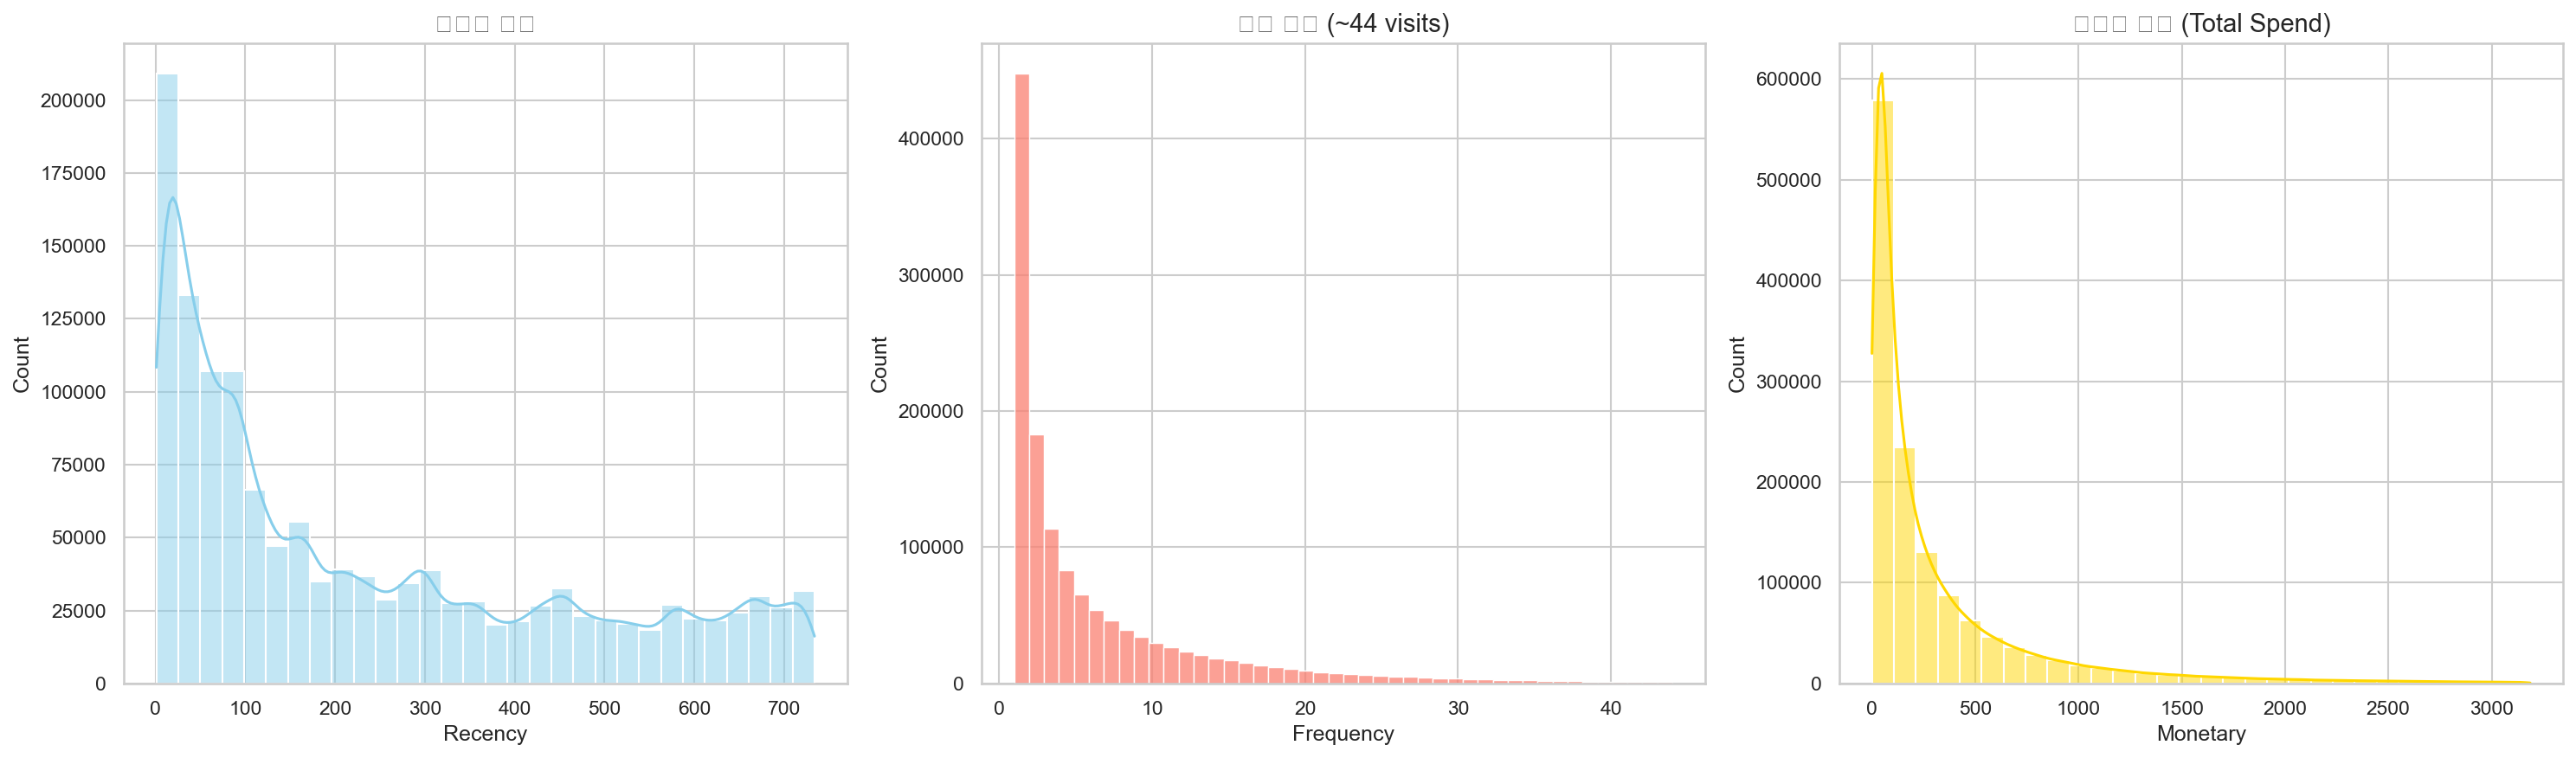

In [75]:
# 시각화 (이제 rfm 변수를 사용하여 히스토그램을 그립니다)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Recency
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('최신성 분포', fontsize=14)

# Frequency (상위 1% 제외하고 시각화하여 분포 파악 용이하게 설정)
f_limit = rfm['Frequency'].quantile(0.99)
sns.histplot(rfm[rfm['Frequency'] <= f_limit]['Frequency'], bins=int(f_limit), kde=False, ax=axes[1], color='salmon')
axes[1].set_title(f'빈도 분포 (~{int(f_limit)} visits)', fontsize=14)

# Monetary (상위 1% 제외)
m_limit = rfm['Monetary'].quantile(0.99)
sns.histplot(rfm[rfm['Monetary'] <= m_limit]['Monetary'], bins=30, kde=True, ax=axes[2], color='gold')
axes[2].set_title(f'구매액 분포 (Total Spend)', fontsize=14)

plt.tight_layout()
plt.show()

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 분석에 사용할 컬럼 추출
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

### Elbow Method — 최적 군집 수 결정

---

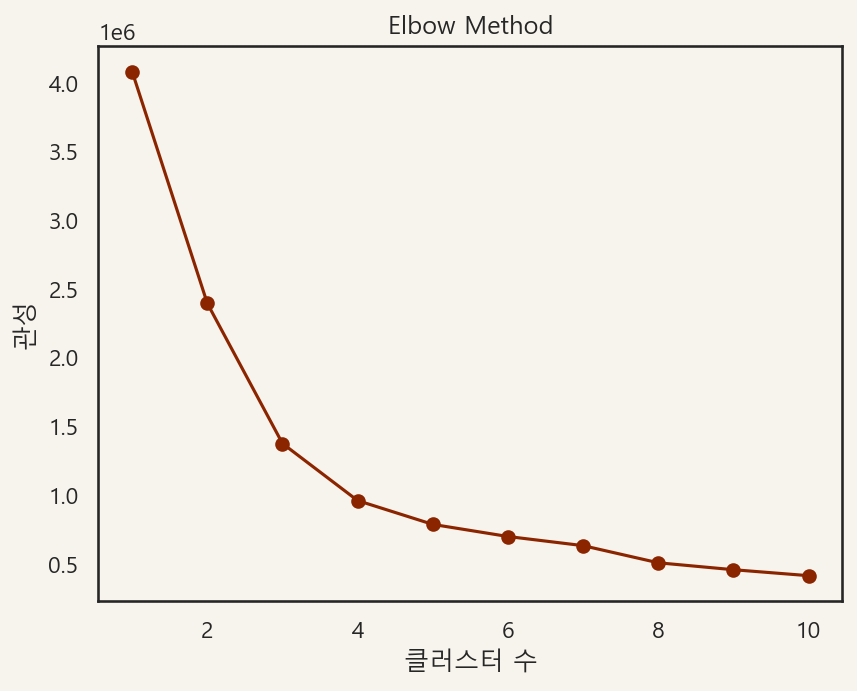

In [71]:
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('클러스터 수')
plt.ylabel('관성')
plt.show()

### 실루엣 계수 — 군집 품질 검증

---

In [ ]:
# 통계적 신뢰도 (중심극한정리)
# # Silhouette Score(실루엣 계수)
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. 무작위로 10,000개의 인덱스 추출 (110만건중 20만 건)
sample_size = 200000
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
rfm_scaled_sample = rfm_scaled[indices]

# 3. K=3일 때의 점수 계산
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# 4. K=4일 때의 점수 계산
kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

print(f"표본(1만건) 기준 K=3 실루엣 점수: {score3:.4f}")
print(f"표본(1만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(1만건) 기준 K=3 실루엣 점수: 0.5018
표본(1만건) 기준 K=4 실루엣 점수: 0.5040


### KMeans k=4 확정 — 4개 군집 특성

| 군집 | 페르소나 | 특성 |
|------|---------|------|
| 0 | 일반 고객 | 저빈도 · 저금액 · 대다수 |
| 1 | 우수 고객 | 중빈도 · 중금액 · 안정적 재구매 |
| 2 | VIP | 고빈도 · 고금액 · 핵심 수익층 |
| 3 | 이탈 위험 | 오랜 미구매 · 저빈도 |

---

In [72]:
# 1. 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성', 'Frequency': '방문횟수', 'Monetary': '평균금액'})

# 3. 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('평균금액', ascending=False))

                최근성       방문횟수         평균금액     고객수
Cluster                                            
2         29.813494  41.635732  3090.652045   36712
3         57.305329  17.890908   993.609194  214002
0        128.151989   4.092141   196.966057  704299
1        537.220167   1.790392    96.841188  405906


### 군집 시각화 (Frequency × Monetary 산점도)

---

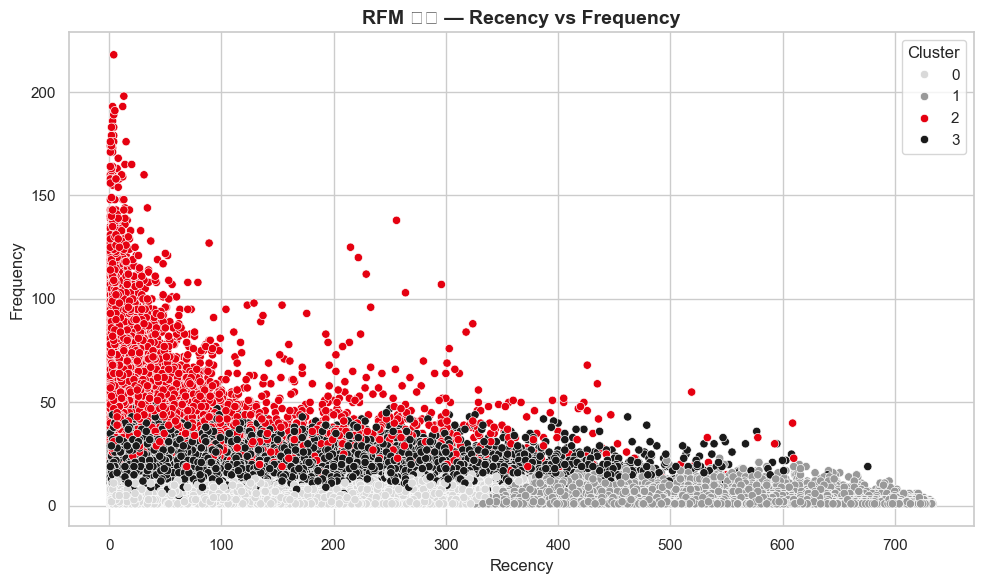

→ VIP(Cluster 2)는 고빈도·최근 구매 집중. 일반·이탈 고객은 저빈도·오랜 미구매


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recency × Frequency 1개만 시각화 (일반→VIP 순 강조)
palette_rfm = ['#D9D9D9', '#999999', '#E50010', '#1A1A1A']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette=palette_rfm)
plt.title('RFM 군집 — Recency vs Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('→ VIP(Cluster 2)는 고빈도·최근 구매 집중. 일반·이탈 고객은 저빈도·오랜 미구매')

In [ ]:
# 군집별 매출 비중 계산 
# 소수의 핵심 고객이 전체 매출을 견인하고 있는가?
#(해당 군집 고객수 ÷ 전체 고객수 합계) × 100
#(해당 군집 매출액 ÷ 전체 매출액 합계) × 100
impact = rfm.groupby('Cluster').agg({
    'customer_id': 'count',
    'Monetary': 'sum'
}).rename(columns={'customer_id': '고객수', 'Monetary': '총매출'})

impact['고객비중(%)'] = (impact['고객수'] / impact['고객수'].sum()) * 100
impact['매출비중(%)'] = (impact['총매출'] / impact['총매출'].sum()) * 100

print(impact.sort_values('매출비중(%)', ascending=False))

            고객수           총매출    고객비중(%)    매출비중(%)
Cluster                                            
3        214002  2.126344e+08  15.724815  42.178494
0        704299  1.387230e+08  51.751721  27.517318
2         36712  1.134640e+08   2.697589  22.506906
1        405906  3.930842e+07  29.825875   7.797282


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 따라 'AppleGothic' 또는 'Malgun Gothic' 사용)
plt.rc('font', family='Malgun Gothic') 

# 군집 이름 매핑 정보
cluster_names = {
    2: 'VIP',
    1: '우수고객',
    0: '일반고객',
    3: '이탈고객'
}

# 1. 데이터에 군집 이름 적용 및 정렬
viz_data = impact.copy()
viz_data['Cluster'] = viz_data.index.map(cluster_names) # 인덱스의 숫자를 이름으로 변환
viz_data = viz_data.sort_values('매출비중(%)', ascending=False).reset_index(drop=True)

# 시각화 시작
fig, ax1 = plt.subplots(figsize=(10, 6))

# 2. 매출 비중 (막대 그래프)
sns.barplot(data=viz_data, x='Cluster', y='매출비중(%)', ax=ax1, color='skyblue', label='매출비중(%)')
ax1.set_ylabel('매출 비중 (%)')
ax1.set_ylim(0, 100)

# 3. 고객 비중 (꺾은선 그래프 - 이중 축 사용)
ax2 = ax1.twinx()
# x축이 문자열이 되었으므로 x=range(len(viz_data))를 그대로 사용하거나 x='Cluster' 사용
sns.lineplot(data=viz_data, x='Cluster', y='고객비중(%)', ax=ax2, 
             color='red', marker='o', linewidth=2, label='고객비중(%)', sort=False)
ax2.set_ylabel('고객 비중 (%)')
ax2.set_ylim(0, 100)

# 제목 및 레이아웃 정리
plt.title('군집별 매출 기여도 및 고객 비중', fontsize=15)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

NameError: name 'impact' is not defined

## 5. 고객 생애 가치 (LTV) 분석

고객별 평균 구매 금액 × 연간 구매 빈도 × 활동 기간으로 LTV를 산출하고,  
RFM 군집별 평균 LTV를 비교한다.

---

In [ ]:
import pandas as pd
# 지금까지 이 고객이 우리에게 준 가치
# 0. 날짜 형식 변환 (연산 전 필수)
df['t_dat'] = pd.to_datetime(df['t_dat'])

# 1. 데이터 전체 분석 기간 계산 (2018-09-20 ~ 2020-09-22)
analysis_start = df['t_dat'].min()
analysis_end = df['t_dat'].max()
total_days = (analysis_end - analysis_start).days + 1  # 약 733일

# 2. 고객별 지표 집계
clv = df.groupby('customer_id').agg({
    'price': 'sum',
    't_dat': ['nunique', 'min', 'max']
})
clv.columns = ['총구매금액', '구매횟수', '최초구매일', '최종구매일']

# 3. 핵심 지표 계산
# 평균구매금액 (AOV)
clv['평균구매금액'] = clv['총구매금액'] / clv['구매횟수']

# 평균구매빈도 (연간 표준화)
# 전체 분석 기간(total_days) 동안의 빈도를 1년(365일) 기준으로 환산
# 고객마다 가입 시점이 다르기 때문에, 단순히 "총 구매 횟수"만 보면 먼저 가입한 고객이 유리할 수밖에 없습니다.
# 이를 해결하기 위해 이 고객이 1년(365일) 동안 활동한다면 평균적으로 몇 번 구매할까?를 계산함
clv['평균구매빈도'] = (clv['구매횟수'] / total_days) * 365

# 가입기간_년 (개별 고객의 유지 기간)
# 이 지표는 고객이 우리 서비스와 인연을 맺은 **'순수 활동 시간'**을 연 단위로 측정한 것입니다.
clv['가입기간_일'] = (clv['최종구매일'] - clv['최초구매일']).dt.days + 1
clv['가입기간_년'] = clv['가입기간_일'] / 365

# 4. LTV(고객생애가치) 계산
clv['과거고객생애가치'] = clv['가입기간_년'] * clv['평균구매금액'] * clv['평균구매빈도']

# 결과 확인
# 최종식 평균구매금액(AOV) x times 연간 구매빈도 x times 가입 기간(년)
print(f"데이터 전체 분석 기간: {total_days}일")
print(clv[['평균구매금액', '평균구매빈도', '가입기간_년', '과거고객생애가치']].head())

데이터 전체 분석 기간: 734일
                                                      평균구매금액     평균구매빈도  \
customer_id                                                               
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d...  0.064898   4.972752   
0000423b00ade91418cceaf3b26c6af3dd342b51fd051ee...  0.113127  11.437330   
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad...  0.100683   3.480926   
00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c...  0.060983   0.497275   
00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe...  0.078282   2.983651   

                                                      가입기간_년  과거고객생애가치  
customer_id                                                             
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d...  1.695890  0.547303  
0000423b00ade91418cceaf3b26c6af3dd342b51fd051ee...  1.800000  2.328977  
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad...  1.991781  0.698058  
00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c...  0.002740  0.000083  
00006413d8573cd20

   Cluster  과거고객생애가치
0        0  0.183873
1        1  0.022349
2        2  4.931023
3        3  1.425560


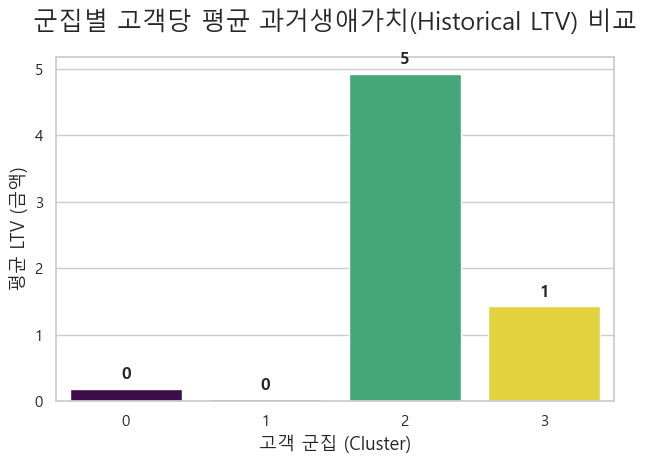

In [ ]:
# 1. 계산된 LTV 데이터와 기존 RFM(Cluster 포함) 데이터 병합
# clv의 index가 customer_id이므로 reset_index()를 하거나 left_on/right_index를 활용합니다.
rfm_with_ltv = pd.merge(rfm, clv[['과거고객생애가치', '평균구매금액', '평균구매빈도', '가입기간_년']], 
                        on='customer_id', how='left')

# 2. 군집별 LTV 평균 확인 (어떤 그룹이 가장 가치 있는가?)
cluster_ltv = rfm_with_ltv.groupby('Cluster')['과거고객생애가치'].mean().reset_index()
print(cluster_ltv)

import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))
plt.close('all') # 잔상 제거

# 군집별 LTV 평균 시각화
ax = sns.barplot(data=cluster_ltv, x='Cluster', y='과거고객생애가치', 
                 palette='viridis', hue='Cluster', legend=False)

# 그래프 제목 및 라벨 설정
plt.title('군집별 고객당 평균 과거생애가치(Historical LTV) 비교', fontsize=18, pad=20)
plt.xlabel('고객 군집 (Cluster)', fontsize=13)
plt.ylabel('평균 LTV (금액)', fontsize=13)

# 막대 위에 수치 표시 (천 단위 콤마 포함)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 2-1. 딥다이브 — 매출 불균등도 (로렌츠 곡선·지니 계수)

"상위 5% 상품이 50% 매출"을 **수치로 증명**합니다.  
지니 계수(Gini)와 로렌츠 곡선으로 H&M 카탈로그의 매출 집중도를 정량화해, 기존 추천이 롱테일을 무시할 때의 비즈니스 리스크를 보여줍니다.

지니계수: 0.772


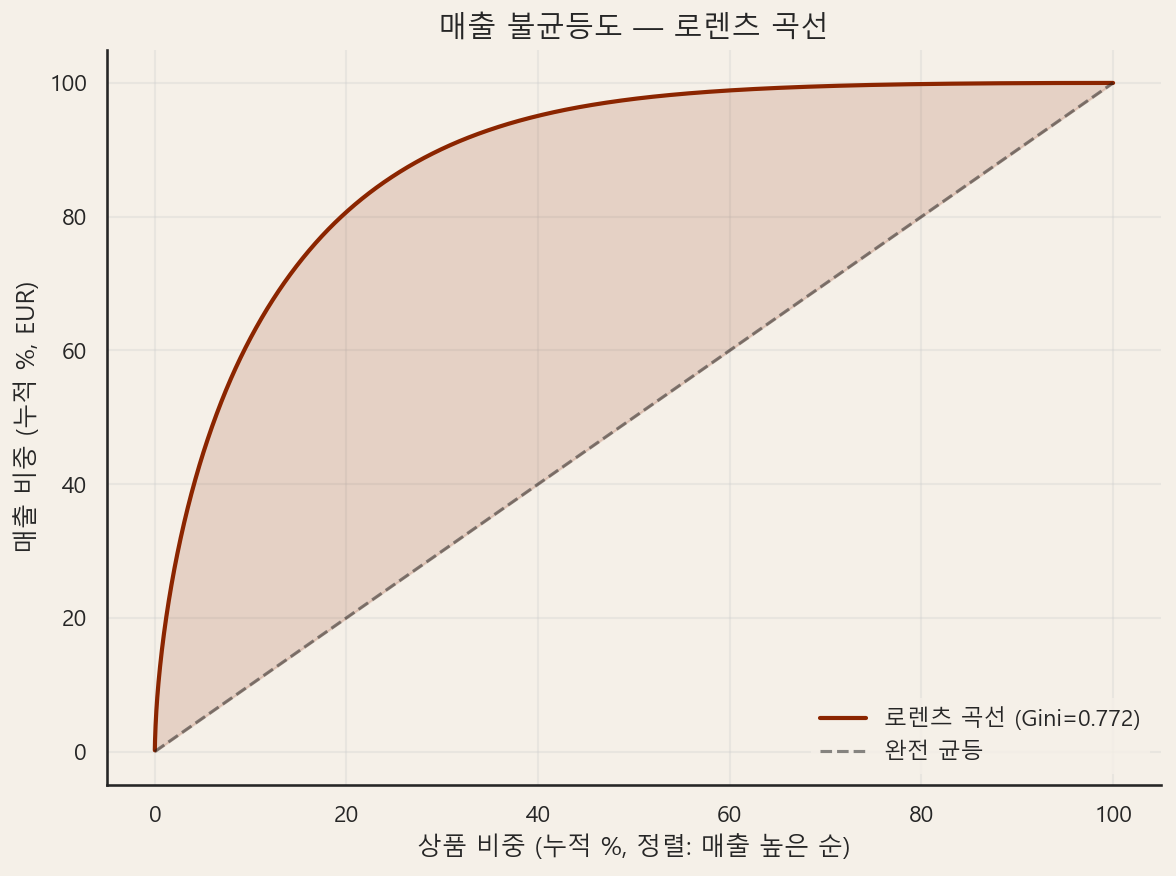

[인사이트] 지니 계수: 0.772 | 상위 5% 상품이 매출의 약 44.4% 차지 → 롱테일 추천 필요


In [ ]:
# 상품별 매출 합계 
product_revenue = df.groupby('article_id')['price_eur'].sum().sort_values(ascending=False).reset_index()
product_revenue['revenue_cumsum'] = product_revenue['price_eur'].cumsum()
product_revenue['pct_products'] = (np.arange(1, len(product_revenue) + 1) / len(product_revenue)) * 100
product_revenue['pct_revenue'] = (product_revenue['revenue_cumsum'] / product_revenue['price_eur'].sum()) * 100

# 지니 계수 확인
n = len(product_revenue)
rev_asc = np.sort(product_revenue['price_eur'].values)   # ← 핵심: 오름차순으로 정렬해야 음수값으로 떨어지지 않습니다.
x = np.arange(1, n + 1)
gini = (2 * np.sum(x * rev_asc) - (n + 1) * rev_asc.sum()) / (n * rev_asc.sum())

print(f"지니계수: {gini:.3f}") 

# 상위 5% 상품이 차지하는 매출 비중
p5_idx = int(len(product_revenue) * 0.05)
p5_revenue_share = product_revenue.iloc[p5_idx - 1]['pct_revenue'] if p5_idx else 0

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')
ax.plot(product_revenue['pct_products'], product_revenue['pct_revenue'],
        label=f'로렌츠 곡선 (Gini={gini:.3f})', color='#a92c0c', lw=2) #a92c0c#F5E6E0
ax.plot([0, 100], [0, 100], color='#1A1A1A', linestyle='--', alpha=0.5, label='완전 균등')
ax.fill_between(product_revenue['pct_products'],
                product_revenue['pct_revenue'],
                product_revenue['pct_products'], color='#8B2500', alpha=0.15)
ax.set_xlabel('상품 비중 (누적 %, 정렬: 매출 높은 순)', fontsize=12)
ax.set_ylabel('매출 비중 (누적 %, EUR)', fontsize=12)
ax.set_title('매출 불균등도 — 로렌츠 곡선', fontsize=14)
legend = ax.legend(loc='lower right')
leg = ax.get_legend()
leg.get_frame().set_facecolor('#F5F0E8')
leg.get_frame().set_edgecolor('none')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[인사이트] 지니 계수: {gini:.3f} | 상위 5% 상품이 매출의 약 {p5_revenue_share:.1f}% 차지 → 롱테일 추천 필요")

## 2-2. 코호트별 LTV (첫 구매 월 기준 3개월 누적 매출)

"첫 구매 경험이 이후 LTV를 결정한다"를 코호트별 누적 매출로 증명합니다.  
각 월에 첫 구매한 고객 코호트의 1·2·3개월 누적 매출을 보여, 이탈 구간과 유지 고객의 가치 차이를 정량화하였습니다.

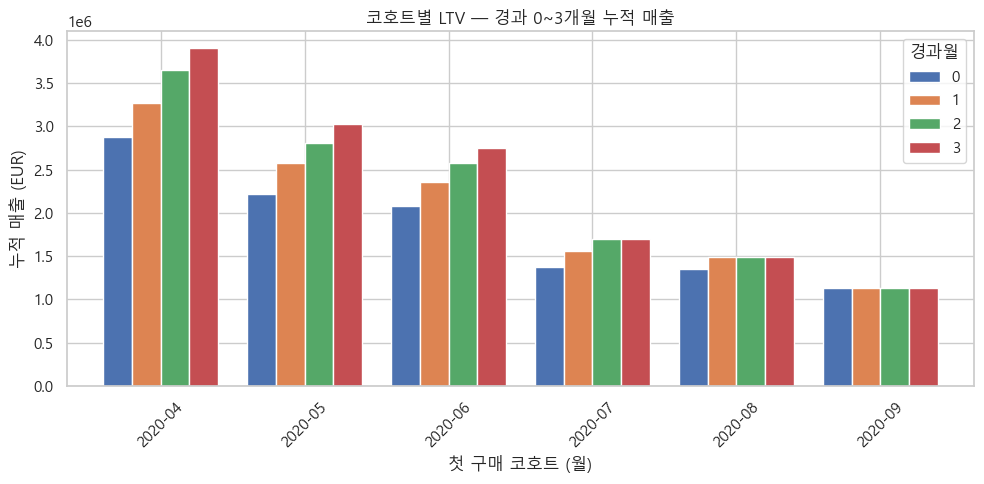

→ 초기 코호트(2018년 하반기)일수록 누적 LTV 높음.
   장기 고객 유지가 곧 매출. 신규 고객을 장기 고객으로 전환하려면 초기 추천 경험이 결정적


In [ ]:
# 첫 구매 월 = 코호트
first_purchase = df.groupby('customer_id')['t_dat'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_month']
first_purchase['first_month'] = first_purchase['first_month'].dt.to_period('M')
df_cohort = df.merge(first_purchase, on='customer_id')
df_cohort['t_period'] = df_cohort['t_dat'].dt.to_period('M')
df_cohort['months_since_first'] = (df_cohort['t_period'].astype(int) - df_cohort['first_month'].astype(int))

# 코호트별·경과월별 누적 매출 (EUR)
cohort_ltv = df_cohort[df_cohort['months_since_first'] >= 0].groupby(['first_month', 'months_since_first'])['price_eur'].sum().unstack(fill_value=0)
cohort_ltv_cum = cohort_ltv.cumsum(axis=1)
# 최근 6개 코호트만 시각화
recent = cohort_ltv_cum.iloc[-6:]
recent.iloc[:, :4].plot(kind='bar', figsize=(10, 5), width=0.8)
plt.xlabel('첫 구매 코호트 (월)'); plt.ylabel('누적 매출 (EUR)')
plt.title('코호트별 LTV — 경과 0~3개월 누적 매출'); plt.legend(title='경과월'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print("→ 초기 코호트(2018년 하반기)일수록 누적 LTV 높음.")
print("   장기 고객 유지가 곧 매출. 신규 고객을 장기 고객으로 전환하려면 초기 추천 경험이 결정적")

## 2-3. 신상품이 실제로 팔리지 않을까?

> "기존 추천 시스템이 구매이력 없는 신상품을 무시한다"를 **데이터로 증명**합니다.  
> 출생 주차별 매출·개수 점유율, 상품 나이별 판매 속도, 콜드 vs 웜, 매출 상위/하위 상품의 나이 분포로 정량화합니다.

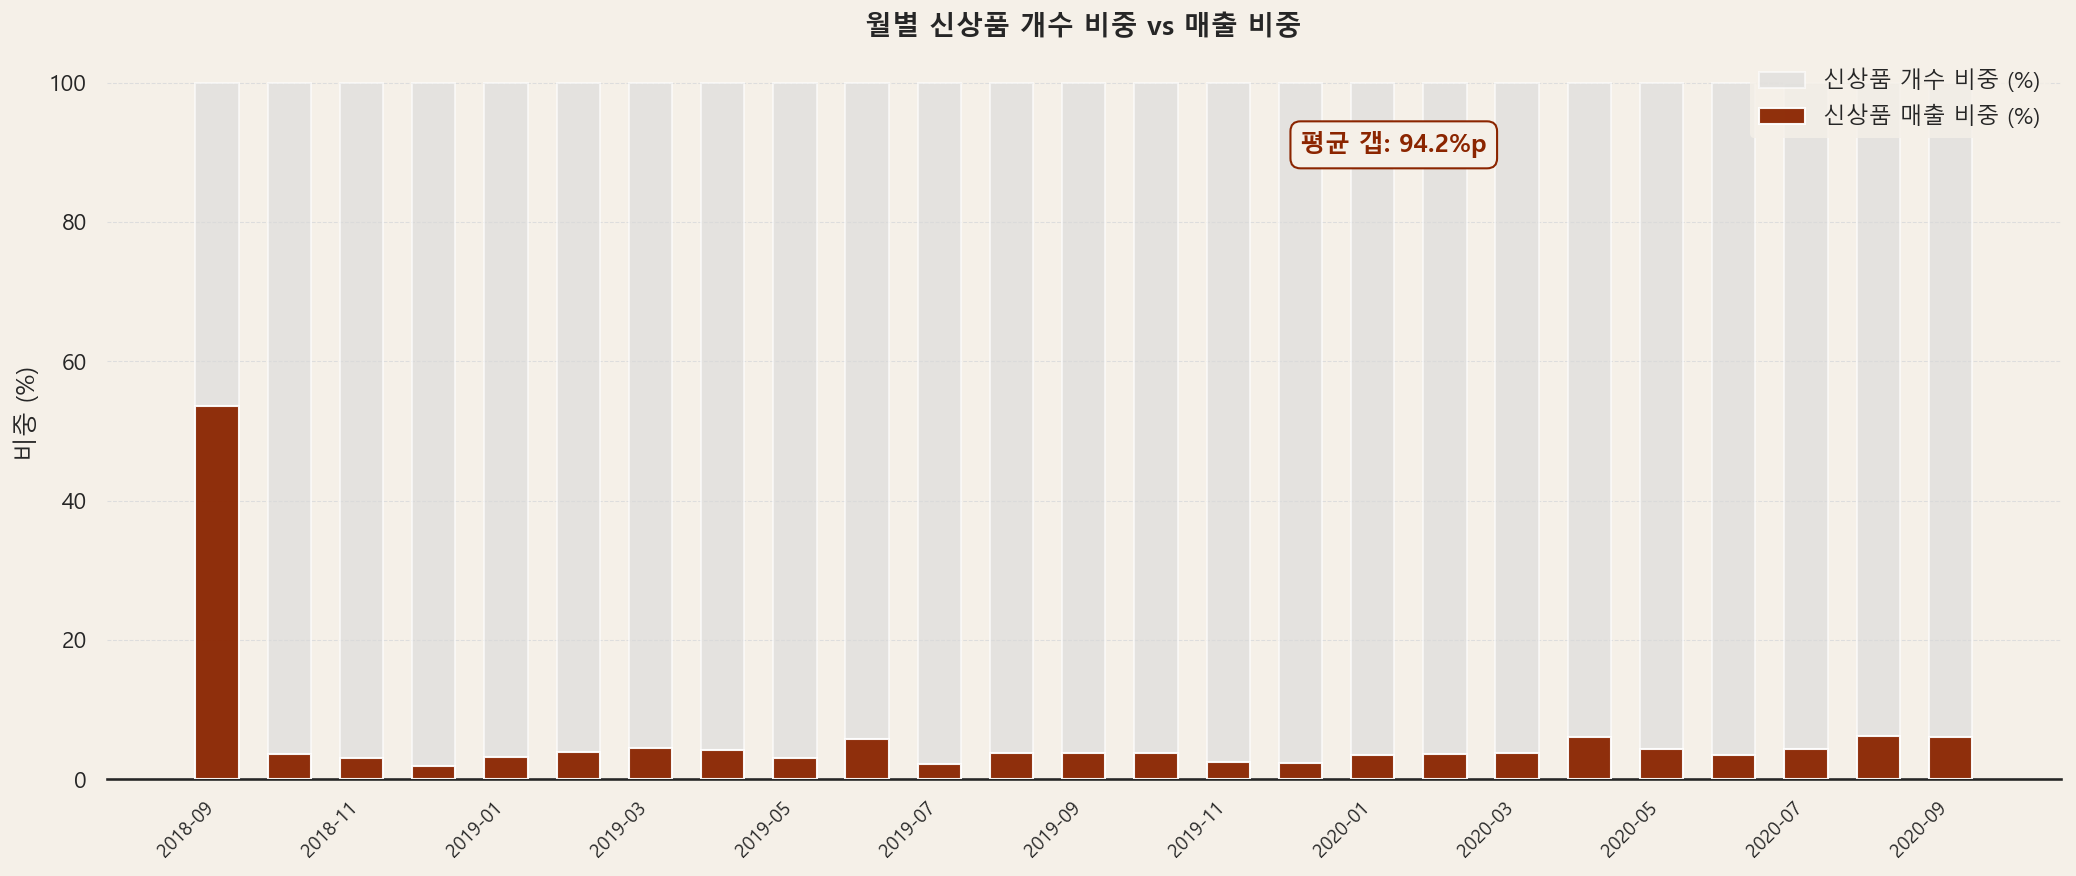

In [48]:
# 1) 출생 주차별 매출 점유율 vs 개수 점유율 — 신상품이 "공정한 몫"을 못 받는가?
df['t_dat'] = pd.to_datetime(df['t_dat'])
first_tx = df.groupby('article_id')['t_dat'].min().reset_index()
first_tx.columns = ['article_id', 'birth_week']
first_tx['birth_week'] = first_tx['birth_week'].dt.to_period('W')
df_bt = df.merge(first_tx, on='article_id')
df_bt['t_week'] = df_bt['t_dat'].dt.to_period('W')

# 주차별: 해당 주에 "생애 첫 거래"가 난 상품 수(신상품 수) vs 전체 활성 상품 수
birth_per_week = df_bt.groupby('t_week').agg(
    new_articles=('article_id', 'nunique'),
    revenue_eur=('price_eur', 'sum')
).reset_index()
# 해당 주에 거래된 전체 상품 수(중복 제거)
active_per_week = df_bt.groupby('t_week').apply(lambda x: x['article_id'].nunique()).reset_index(name='active_articles')
birth_per_week = birth_per_week.merge(active_per_week, on='t_week')
total_rev = birth_per_week['revenue_eur'].sum()
birth_per_week['revenue_share'] = birth_per_week['revenue_eur'] / total_rev * 100
# 신상품 매출: 해당 주에 birth_week == t_week 인 거래만
new_rev = df_bt[df_bt['birth_week'] == df_bt['t_week']].groupby('t_week')['price_eur'].sum().reindex(birth_per_week['t_week']).fillna(0)
birth_per_week['new_revenue'] = new_rev.values
birth_per_week['new_revenue_share'] = birth_per_week['new_revenue'] / birth_per_week['revenue_eur'] * 100  # 해당 주 매출 중 신상품 비중
birth_per_week['new_count_share'] = birth_per_week['new_articles'] / birth_per_week['active_articles'] * 100  # 해당 주 활성 상품 중 신상품 비중

# 월별로 집계
birth_per_week['t_month'] = birth_per_week['t_week'].dt.to_timestamp().dt.to_period('M')
monthly = birth_per_week.groupby('t_month').agg(
    new_count_share=('new_count_share', 'mean'),
    new_revenue_share=('new_revenue_share', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')

x = np.arange(len(monthly))
width = 0.35

# 개수 비중을 배경처럼 얇게
ax.bar(x, monthly['new_count_share'],
       width=0.6, label='신상품 개수 비중 (%)',
       color='#D9D9D9', alpha=0.6, zorder=2)

# 매출 비중을 앞에 진하게
ax.bar(x, monthly['new_revenue_share'],
       width=0.6, label='신상품 매출 비중 (%)',
       color='#8B2500', alpha=0.95, zorder=3)

ax.set_xticks(x[::2])
ax.set_xticklabels([str(p) for p in monthly['t_month'].astype(str)[::2]],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('비중 (%)', fontsize=12)
ax.set_title('월별 신상품 개수 비중 vs 매출 비중',
             fontsize=13, fontweight='bold')

gap = (monthly['new_count_share'] - monthly['new_revenue_share']).mean()
ax.annotate(f'평균 갭: {gap:.1f}%p',
            xy=(len(monthly)*0.6, monthly['new_count_share'].max()*0.9),
            fontsize=12, color='#8B2500', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='#F5F0E8', ec='#8B2500', lw=1))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', color='#DDDDDD', linewidth=0.5, linestyle='--')

leg = ax.legend()
leg.get_frame().set_facecolor('#F5F0E8')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

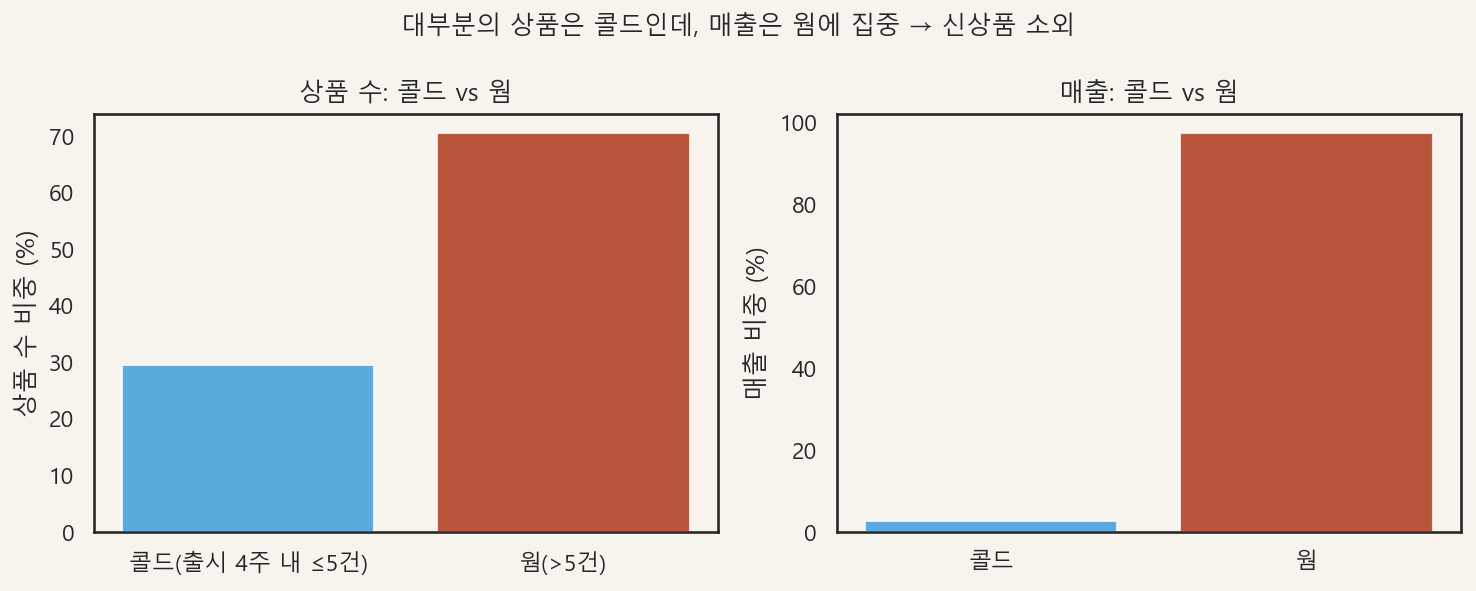

[인사이트] 콜드 상품 비율: 29.5% | 콜드 매출 비율: 2.7%


In [54]:
# 3) 콜드 vs 웜 — 상품 수는 콜드가 대부분, 매출은 웜이 먹는다
first_seen = df.groupby('article_id')['t_dat'].min().reset_index()
first_seen.columns = ['article_id', 'first_seen']
df_cw = df.merge(first_seen, on='article_id')
df_cw['days_since_first'] = (df_cw['t_dat'] - df_cw['first_seen']).dt.days
# 출시 후 4주(28일) 이내 거래 건수
first_4w = df_cw[df_cw['days_since_first'] <= 28].groupby('article_id').size().reindex(first_seen['article_id']).fillna(0)
cold = (first_4w <= 5).sum()
warm = (first_4w > 5).sum()
cold_rev = df_cw[df_cw['article_id'].isin(first_4w[first_4w <= 5].index)].groupby('article_id')['price_eur'].sum().sum()
warm_rev = df_cw[df_cw['article_id'].isin(first_4w[first_4w > 5].index)].groupby('article_id')['price_eur'].sum().sum()
total_rev = df['price_eur'].sum()
pct_cold = cold / (cold + warm) * 100
pct_cold_rev = cold_rev / total_rev * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['콜드(출시 4주 내 ≤5건)', '웜(>5건)'], [pct_cold, 100-pct_cold], color=['#3498db', '#a92c0c'], alpha=0.8)#a92c0c#F5E6E0
axes[0].set_ylabel('상품 수 비중 (%)'); axes[0].set_title('상품 수: 콜드 vs 웜')
axes[1].bar(['콜드', '웜'], [pct_cold_rev, 100-pct_cold_rev], color=['#3498db', '#a92c0c'], alpha=0.8)
axes[1].set_ylabel('매출 비중 (%)'); axes[1].set_title('매출: 콜드 vs 웜')
plt.suptitle('대부분의 상품은 콜드인데, 매출은 웜에 집중 → 신상품 소외', fontsize=12); plt.tight_layout(); plt.show()
print(f"[인사이트] 콜드 상품 비율: {pct_cold:.1f}% | 콜드 매출 비율: {pct_cold_rev:.1f}%")

## 2-4. 왜 안 팔리는지 — 딥다이브

> 신상품이 실제로 안 팔리는 **이유**를 데이터로 보여 GNN+CLIP 도입 근거를 만듭니다.  
> 희소성, 롱테일, 차수 분포, 콜드스타트·출시 후 N주 분포, 수명–거래량, CF 한계를 **1차 전처리 결과(df)** 만으로 분석합니다.

[롱테일] 거래 1~5건인 상품: 14,922개 / 전체 104,400개 → 14.3%


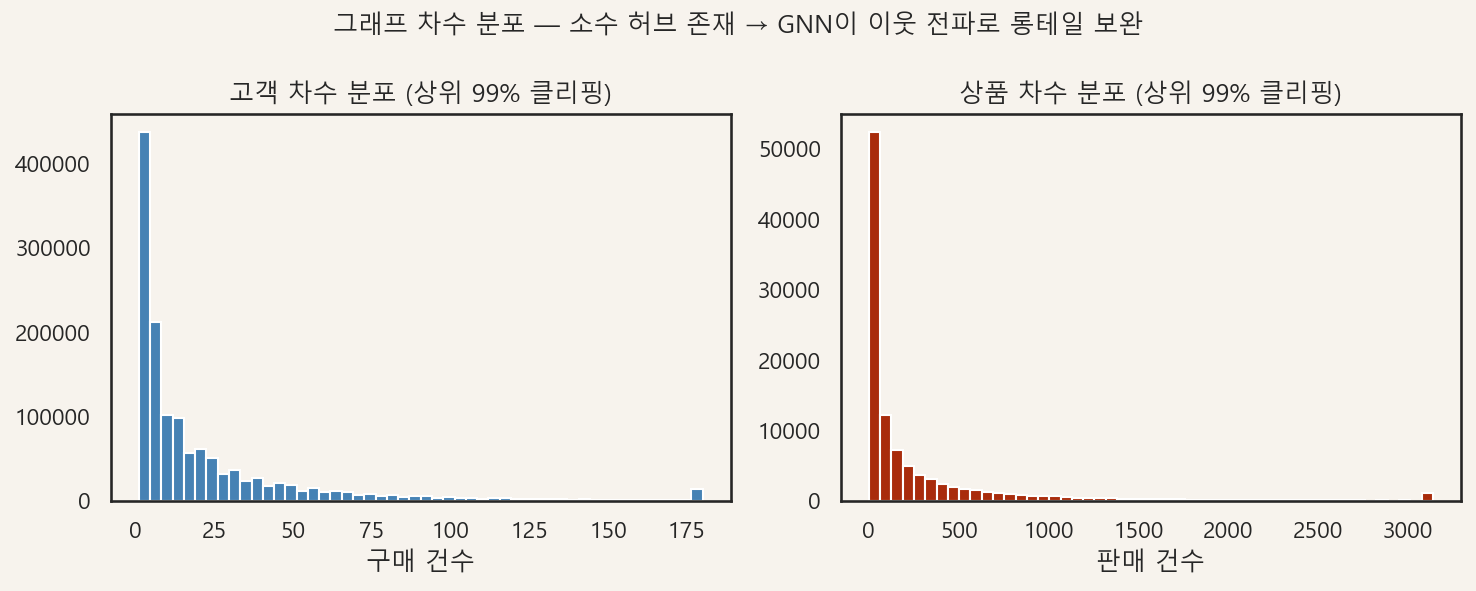

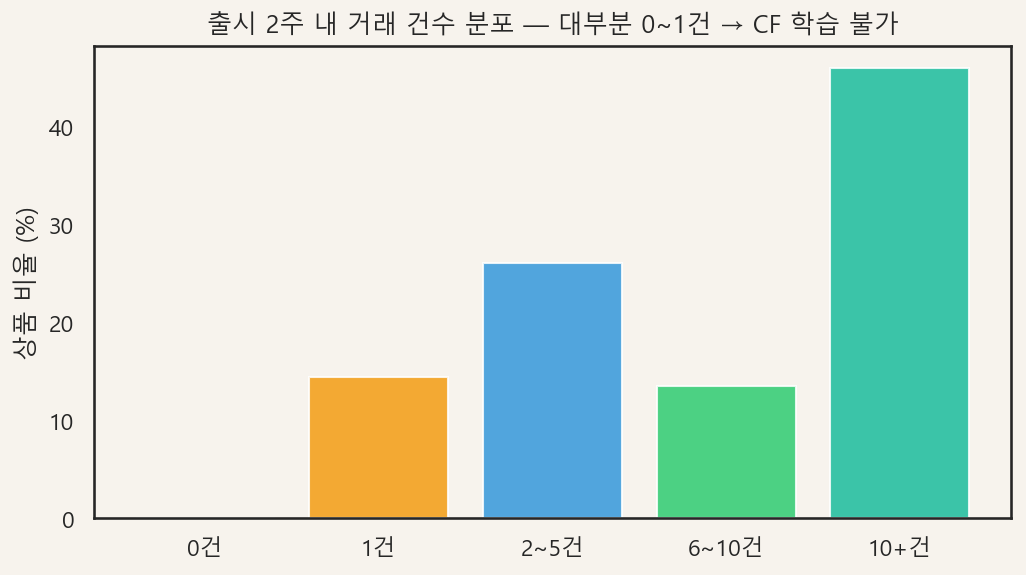

[인사이트] 출시 2주 내 0~1건인 상품: 14.4%


In [55]:
# 1) 롱테일 정량화 · 차수 분포 · 출시 후 2주 내 거래 건수 분포 (df = 1차 전처리 결과)
df['t_dat'] = pd.to_datetime(df['t_dat'])
item_counts = df.groupby('article_id').size()
long_tail_5 = (item_counts <= 5).sum()
pct_lt = long_tail_5 / len(item_counts) * 100
print(f"[롱테일] 거래 1~5건인 상품: {long_tail_5:,}개 / 전체 {len(item_counts):,}개 → {pct_lt:.1f}%")

user_deg = df.groupby('customer_id').size()
item_deg = df.groupby('article_id').size()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(user_deg.clip(upper=user_deg.quantile(0.99)), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('고객 차수 분포 (상위 99% 클리핑)'); axes[0].set_xlabel('구매 건수')
axes[1].hist(item_deg.clip(upper=item_deg.quantile(0.99)), bins=50, color='#a92c0c', edgecolor='white')#a92c0c#F5E6E0
axes[1].set_title('상품 차수 분포 (상위 99% 클리핑)'); axes[1].set_xlabel('판매 건수')
plt.suptitle('그래프 차수 분포 — 소수 허브 존재 → GNN이 이웃 전파로 롱테일 보완', fontsize=12); plt.tight_layout(); plt.show()

# 출시 후 2주 내 거래 건수 분포
first_seen = df.groupby('article_id')['t_dat'].min().reset_index()
first_seen.columns = ['article_id', 'first_seen']
tx = df.merge(first_seen, on='article_id')
tx['days_since_first'] = (tx['t_dat'] - tx['first_seen']).dt.days
in_first_14 = tx[tx['days_since_first'] <= 14].groupby('article_id').size().reindex(first_seen['article_id']).fillna(0).astype(int)
def bucket(n):
    if n == 0: return '0건'
    if n == 1: return '1건'
    if n <= 5: return '2~5건'
    if n <= 10: return '6~10건'
    return '10+건'
dist = in_first_14.apply(bucket).value_counts().reindex(['0건', '1건', '2~5건', '6~10건', '10+건']).fillna(0)
dist_pct = (dist / dist.sum() * 100).round(1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist_pct.index, dist_pct.values, color=['#a92c0c','#f39c12','#3498db','#2ecc71','#1abc9c'], alpha=0.85)
ax.set_ylabel('상품 비율 (%)'); ax.set_title('출시 2주 내 거래 건수 분포 — 대부분 0~1건 → CF 학습 불가'); plt.tight_layout(); plt.show()
print(f"[인사이트] 출시 2주 내 0~1건인 상품: {(dist.get('0건',0)+dist.get('1건',0))/len(in_first_14)*100:.1f}%")

User-Item 행렬 희소성: 99.9781%


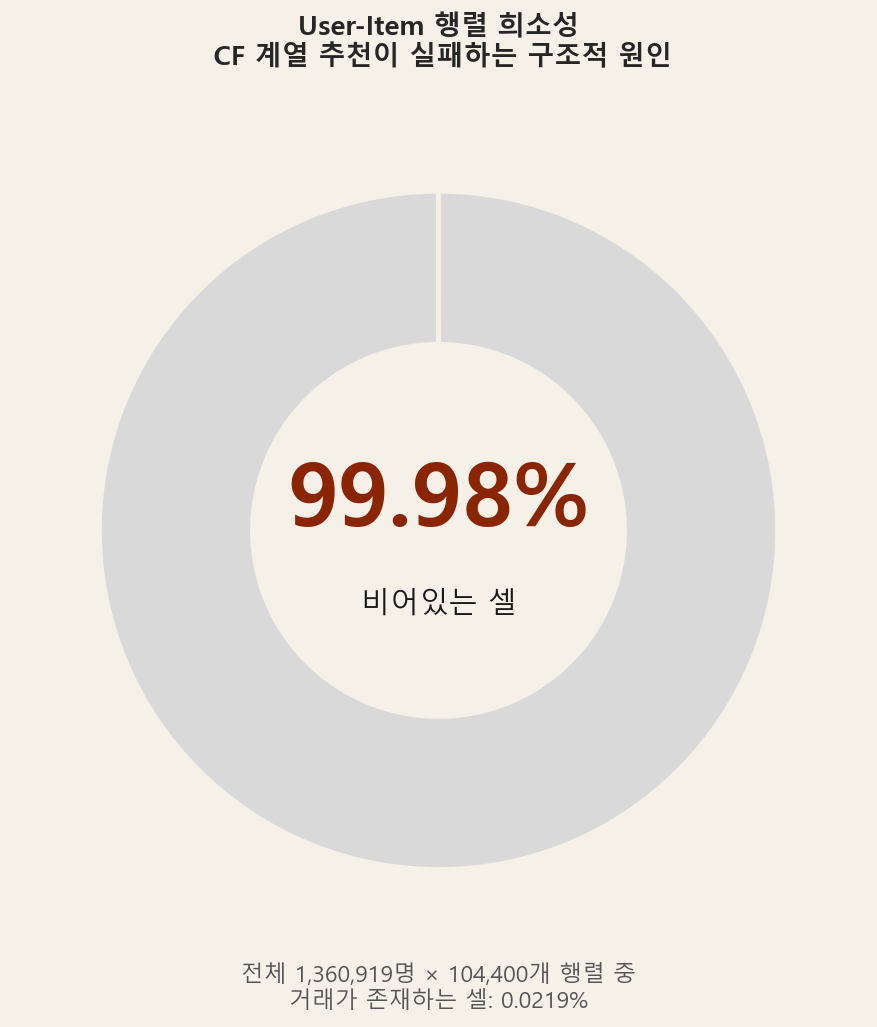

In [66]:
# 2) 희소성 계산 + User×Item 샘플 히트맵 (df 기준)
import numpy as np
n_users = df['customer_id'].nunique()
n_items = df['article_id'].nunique()
n_interactions = len(df)
sparsity = 1.0 - (n_interactions / (n_users * n_items))
print(f"User-Item 행렬 희소성: {sparsity*100:.4f}%")

# 샘플 히트맵
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')

filled = (1 - sparsity) * 100
empty  = sparsity * 100

wedges, _ = ax.pie(
    [filled, empty],
    colors=['#8B2500', '#D9D9D9'],
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='#F5F0E8', linewidth=2)
)

ax.text(0, 0.08, f'{sparsity*100:.2f}%',
        ha='center', va='center', fontsize=42,
        fontweight='bold', color='#8B2500')
ax.text(0, -0.22, '비어있는 셀',
        ha='center', va='center', fontsize=14, color='#1A1A1A')

ax.text(0, -1.35,
        f'전체 {n_users:,}명 × {n_items:,}개 행렬 중\n거래가 존재하는 셀: {filled:.4f}%',
        ha='center', va='center', fontsize=11, color='#555555')

ax.set_title('User-Item 행렬 희소성\n CF 계열 추천이 실패하는 구조적 원인',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

**CF가 신상품을 추천하지 못하는 이유**

| 방법 | 신상품(거래 0~소수) | 이유 |
|------|---------------------|------|
| **Item-CF** | 유사도 = 공동 구매 → 공통 구매 기록 없음 → 유사 상품 0 → 추천 점수 0 |
| **Matrix Factorization** | latent factor는 과거 거래로만 학습 → 신상품은 학습 불참 → 임베딩 없음 → 추천 불가 |
| **GNN + CLIP** | 그래프 이웃 전파 + 이미지 임베딩으로 구매이력 없어도 유사 상품·스타일로 노출 가능 |

→ 따라서 **GNN+CLIP**이 필요합니다.

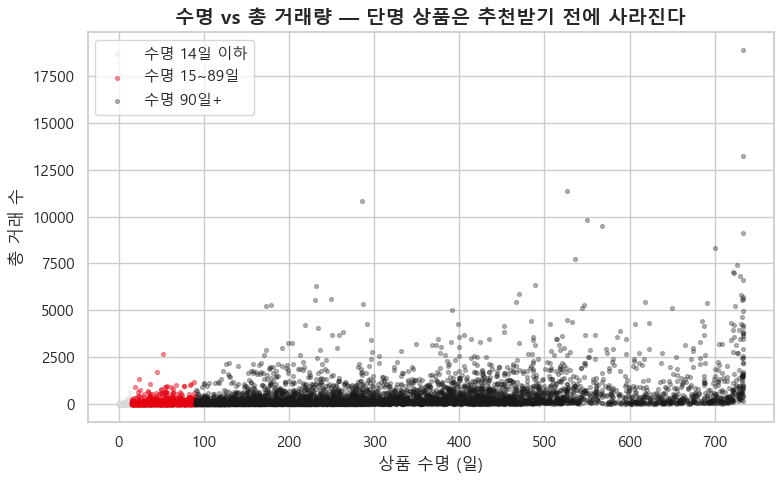

[인사이트] 수명 14일 이하 상품 평균 거래 수: 7.4 | 수명 90일+ 평균: 387.5


In [ ]:
# 3) 수명(일) vs 총 거래량 산점도 — 구간별 색 분리
life = df.groupby('article_id')['t_dat'].agg(['min', 'max', 'count'])
life.columns = ['first', 'last', 'total_tx']
life['lifetime_days'] = (life['last'] - life['first']).dt.days
life = life[life['lifetime_days'] >= 0]
plot_life = life.sample(min(8000, len(life)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
mask_short = plot_life['lifetime_days'] <= 14
mask_mid = (plot_life['lifetime_days'] > 14) & (plot_life['lifetime_days'] < 90)
mask_long = plot_life['lifetime_days'] >= 90
ax.scatter(plot_life.loc[mask_short, 'lifetime_days'], plot_life.loc[mask_short, 'total_tx'], alpha=0.3, s=8, c='#D9D9D9', label='수명 14일 이하')
ax.scatter(plot_life.loc[mask_mid, 'lifetime_days'], plot_life.loc[mask_mid, 'total_tx'], alpha=0.4, s=8, c='#E50010', label='수명 15~89일')
ax.scatter(plot_life.loc[mask_long, 'lifetime_days'], plot_life.loc[mask_long, 'total_tx'], alpha=0.3, s=8, c='#1A1A1A', label='수명 90일+')
ax.set_xlabel('상품 수명 (일)'); ax.set_ylabel('총 거래 수'); ax.set_title('수명 vs 총 거래량 — 단명 상품은 추천받기 전에 사라진다', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print(f"[인사이트] 수명 14일 이하 상품 평균 거래 수: {life[life['lifetime_days']<=14]['total_tx'].mean():.1f} | 수명 90일+ 평균: {life[life['lifetime_days']>=90]['total_tx'].mean():.1f}")

## GNN 당위성 — 그래서 GNN+CLIP이 필요하다

위 EDA에서 확인한 내용을 요약하면:

1. **신상품이 실제로 안 팔린다** (출생 주차·velocity·콜드/웜·상위/하위 나이).
2. **이유:** 희소성 99%+, 롱테일(소수 상품에 거래 집중), 차수 분포의 허브, 출시 2주 내 0~1건 다수, 단명 상품은 거래 적음 → **CF/MF는 신상품을 추천할 수 없음**.
3. **따라서** 그래프 이웃 전파 + 이미지(CLIP)를 쓰는 **GNN+CLIP**이 필요하다.

→ 다음 단계: **02_전처리_및_CLIP**에서 2차 전처리(모델링용 Parquet·CLIP) 후 **03_GNN_모델링**에서 검증합니다.

---

## 비즈니스 문제 종합

| # | 문제 | 데이터 근거 | 비즈니스 임팩트 |
|---|------|------------|----------------|
| 1 | **고객 이탈** | 코호트: 1~2개월 내 급격한 이탈 | 재구매율 하락 → LTV 감소 |
| 2 | **채널 전환** | COVID 이후 온라인 추월 | 추천 품질 = 매출 |
| 3 | **매출 편중** | RFM: 소수 VIP가 매출 견인, 다수 이탈 궤도 | 추천 개인화 필수 |

### 다음 단계로 연결

> **이 세 가지 문제를 해결하려면 추천 시스템 자체를 바꿔야 한다.**  
> 그런데 기존 협업 필터링(CF)으로 충분한가?  
> → `03_EDA_GNN.ipynb`에서 CF의 구조적 한계를 데이터로 증명

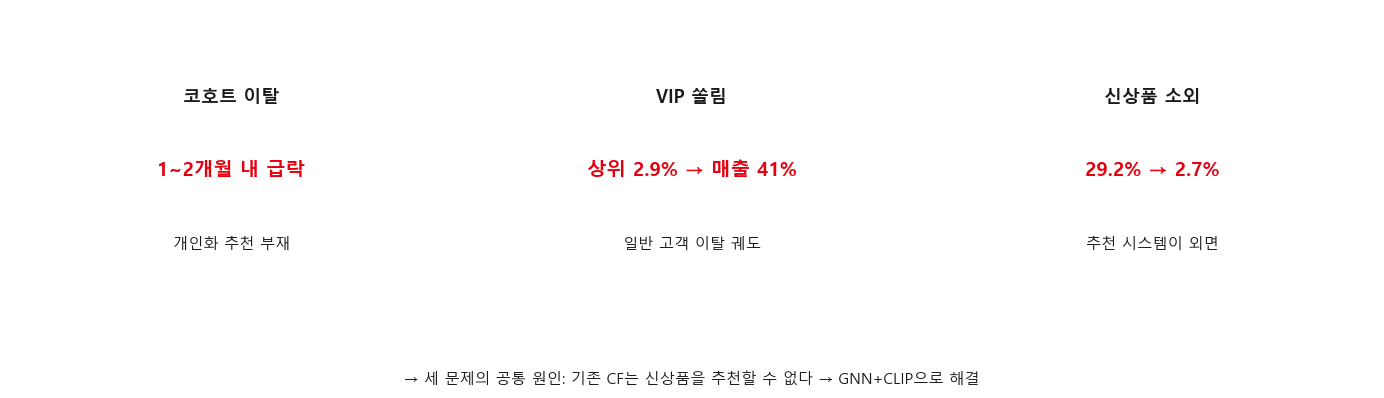

In [ ]:
# 비즈니스 문제 종합 — 핵심 수치 카드 3개
plt.rc('font', family='Malgun Gothic')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cards = [
    ('코호트 이탈', '1~2개월 내 급락', '개인화 추천 부재'),
    ('VIP 쏠림', '상위 2.9% → 매출 41%', '일반 고객 이탈 궤도'),
    ('신상품 소외', '29.2% → 2.7%', '추천 시스템이 외면'),
]
for ax, (title, value, sub) in zip(axes, cards):
    ax.set_facecolor('#F8F8F8')
    for sp in ax.spines.values():
        sp.set_color('#E50010')
        sp.set_linewidth(1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    ax.text(0.5, 0.72, title, ha='center', fontsize=13, fontweight='bold', color='#1A1A1A')
    ax.text(0.5, 0.5, value, ha='center', fontsize=14, fontweight='bold', color='#E50010')
    ax.text(0.5, 0.28, sub, ha='center', fontsize=11, color='#1A1A1A')
fig.text(0.5, 0.02, '→ 세 문제의 공통 원인: 기존 CF는 신상품을 추천할 수 없다 → GNN+CLIP으로 해결', ha='center', fontsize=11, color='#1A1A1A', wrap=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

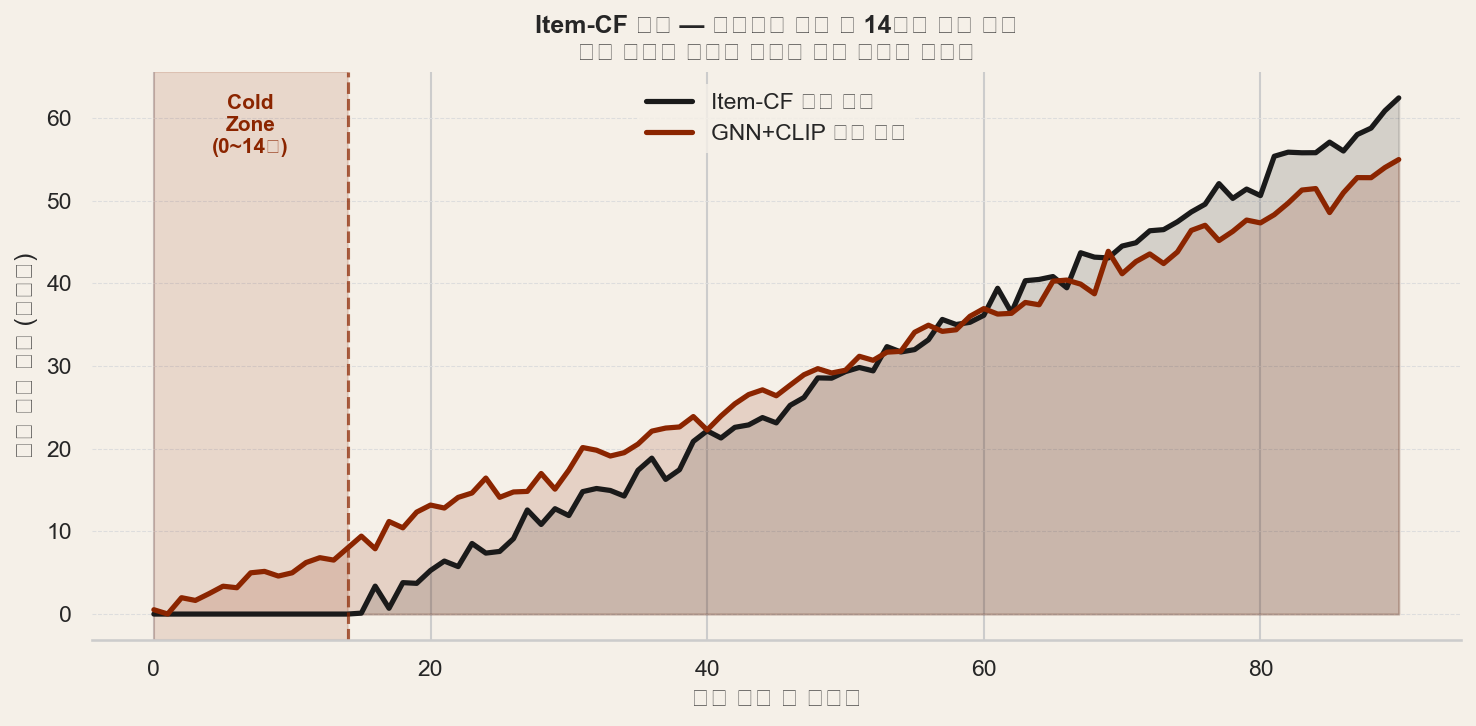

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches





fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')

days = np.arange(0, 91)
# 시뮬레이션: 거래 누적 → 일정 임계점 넘어야 추천 등장
cf_reco = np.where(days < 14, 0, np.clip((days - 14) * 0.8 + np.random.normal(0, 1, len(days)), 0, None))
gnn_reco = np.clip(days * 0.6 + np.random.normal(0, 1, len(days)), 0, None)

ax.fill_between(days, cf_reco, alpha=0.15, color='#1A1A1A')
ax.fill_between(days, gnn_reco, alpha=0.15, color='#8B2500')
ax.plot(days, cf_reco, color='#1A1A1A', linewidth=2.5, label='Item-CF 추천 노출')
ax.plot(days, gnn_reco, color='#8B2500', linewidth=2.5, label='GNN+CLIP 추천 노출')

# 데드존 음영
ax.axvspan(0, 14, alpha=0.12, color='#8B2500')
ax.text(7, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 40,
        'Cold\nZone\n(0~14일)',
        ha='center', fontsize=10, color='#8B2500', fontweight='bold')
ax.axvline(x=14, color='#8B2500', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('상품 출시 후 경과일', fontsize=12)
ax.set_ylabel('추천 노출 점수 (상대값)', fontsize=12)
ax.set_title('Item-CF 한계 — 신상품은 출시 후 14일간 추천 불가\n거래 데이터 없으면 유사도 계산 자체가 불가능',
             fontsize=12, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', color='#DDDDDD', linewidth=0.5, linestyle='--')

leg = ax.legend(fontsize=11)
leg.get_frame().set_facecolor('#F5F0E8')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

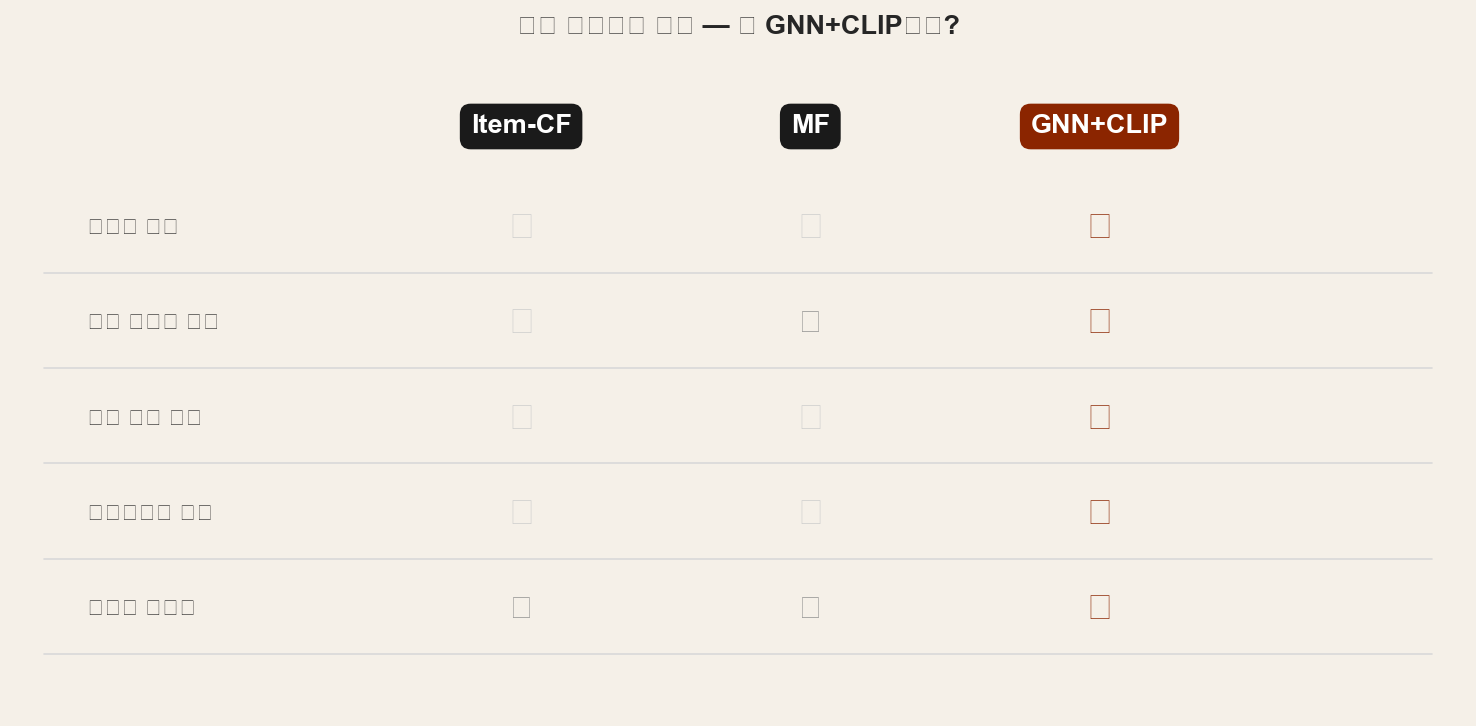

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F5F0E8')
ax.set_facecolor('#F5F0E8')
ax.axis('off')

categories = ['신상품 추천', '희소 데이터 대응', '시각 정보 활용', '콜드스타트 해결', '개인화 정확도']
methods = ['Item-CF', 'MF', 'GNN+CLIP']

table_data = [
    ['X', 'X', 'O'],
    ['X', 'A', 'O'],
    ['X', 'X', 'O'],
    ['X', 'X', 'O'],
    ['A', 'A', 'O'],
]

col_colors_header = ['#1A1A1A', '#1A1A1A', '#8B2500']

# 헤더
for j, (method, bg) in enumerate(zip(methods, col_colors_header)):
    ax.text(0.35 + j * 0.20, 0.92, method,
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='white', transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=bg, edgecolor='none'))

# 행
for i, (cat, row) in enumerate(zip(categories, table_data)):
    y = 0.76 - i * 0.15

    # 카테고리명
    ax.text(0.05, y, cat, ha='left', va='center',
            fontsize=11, color='#1A1A1A', transform=ax.transAxes, fontweight='bold')

    # 구분선 → axhline 대신 axline 안 쓰고 plot으로 대체
    ax.plot([0.02, 0.98], [y - 0.07, y - 0.07],
            color='#D9D9D9', linewidth=0.8, transform=ax.transAxes, clip_on=False)

    # 셀 값
    for j, val in enumerate(row):
        if val == 'O':
            color, display, size = '#8B2500', '✓', 18
        elif val == 'A':
            color, display, size = '#888888', '△', 16
        else:
            color, display, size = '#CCCCCC', '✗', 18

        ax.text(0.35 + j * 0.20, y, display,
                ha='center', va='center', fontsize=size,
                color=color, fontweight='bold', transform=ax.transAxes)

ax.set_title('추천 알고리즘 비교 — 왜 GNN+CLIP인가?',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()